# 03 — Exploratory Data Analysis & Dimensionality Reduction

**Purpose:** Comprehensive exploration of the cleaned Steam games dataset to inform ML model development in Phase 4.

**Data source:** `cleaned_games` table from `steam.db`, created by `02_data_cleaning.ipynb`.

**Analysis goals:**
1. Understand the distribution and relationships of key features
2. Apply dimensionality reduction (PCA) to understand feature structure
3. Validate target variable construction (regression & classification)
4. Identify multicollinearity and recommend feature engineering strategies
5. Provide actionable insights for Phase 4 model development

**Key outputs:**
- PCA analysis with component interpretation
- Distribution analysis of numerical and categorical features
- Target variable validation (current_price, value_retention_tier)
- Correlation analysis and multicollinearity detection
- Feature importance rankings
- Recommendations for preprocessing and model selection

## Setup

In [3]:
import sys
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD

import warnings
warnings.filterwarnings('ignore')

# Bootstrap: make src importable
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9

# Color palettes (matching project style)
PALETTE = sns.color_palette('husl', 10)
TIER_COLORS = {
    'Premium Hold': '#2ecc71',
    'Standard Depreciation': '#3498db',
    'Heavy Discount': '#f39c12',
    'Permanent Bargain': '#e74c3c'
}

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [4]:
# Find and connect to database
# Try multiple possible locations
possible_paths = [
    PROJECT_ROOT / 'data' / 'steam.db',  # Standard project structure
    PROJECT_ROOT / 'data' / 'steam 1.db',  # Alternative name
    Path('steam 1.db'),  # Current directory
    Path('steam.db'),  # Current directory alternative
    Path('../data/steam.db'),  # Up one level
    Path('data/steam.db'),  # Subdirectory
]

db_path = None
for path in possible_paths:
    if path.exists():
        db_path = path
        break

if db_path is None:
    raise FileNotFoundError(
        f"Database file not found. Searched in:\n" +
        "\n".join(f"  - {p}" for p in possible_paths) +
        "\n\nRun 01_data_collection.ipynb and 02_data_cleaning.ipynb first."
    )

print(f"Found database: {db_path}")
conn = sqlite3.connect(db_path)

# Check available tables
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name",
    conn
)['name'].tolist()

print(f"Tables ({len(tables)}): {tables}")

if 'cleaned_games' not in tables:
    raise ValueError(
        "Table 'cleaned_games' not found in database.\n"
        "Please run 02_data_cleaning.ipynb first to create this table."
    )

Found database: C:\Users\jlgel\Downloads\Y2T2-Final-Project\data\steam 1.db
Tables (15): ['app_list', 'cleaned_discount_panel', 'cleaned_games', 'cleaned_sale_events', 'game_categories', 'game_genres', 'games', 'itad_mapping', 'player_counts', 'price_history', 'review_timestamps', 'reviews_summary', 'steamcharts_history', 'steamspy', 'steamspy_tags']


In [5]:
# Load cleaned data
df = pd.read_sql_query('SELECT * FROM cleaned_games', conn)
print(f'Loaded {len(df):,} games from cleaned_games')
print(f'Features: {len(df.columns)}')
print(f'\nColumns: {list(df.columns)}')

Loaded 4,946 games from cleaned_games
Features: 32

Columns: ['appid', 'title', 'developer', 'publisher', 'release_date', 'days_since_release', 'release_year', 'release_month', 'initial_price', 'current_price', 'discount_depth', 'price_tier', 'price_retention_ratio', 'price_retention', 'value_retention_tier', 'review_score', 'total_reviews', 'total_positive', 'total_negative', 'ownership_midpoint', 'owners', 'log_ownership', 'units_sold_estimate', 'primary_genre', 'developer_tier', 'is_multiplayer', 'has_controller_support', 'achievements_total', 'ever_discounted', 'max_discount_ever', 'player_engagement', 'avg_recent_players']


In [6]:
# APPLY PHASE 4 MODELING FILTERS
# These filters match exactly what will be used in 04_ml_part1_*.ipynb

print("\n" + "="*80)
print("DATA FILTERING: MATCHING PHASE 4 MODELING DATASET")
print("="*80)

print(f"\nStarting with: {len(df):,} games from cleaned_games table")

# FILTER 1: Remove free games (initial_price = 0)
print(f"\n" + "-"*80)
print("FILTER 1: initial_price > 0 (remove free-to-play games)")
print("-"*80)
free_games = (df['initial_price'] == 0).sum()
print(f"  Games with initial_price = 0: {free_games:,}")

df = df[df['initial_price'] > 0].copy()
print(f"  Remaining: {len(df):,} games")
print(f"  ✓ Removed {free_games:,} free games")

# FILTER 2: Remove rows with missing required features
print(f"\n" + "-"*80)
print("FILTER 2: Non-null required features and targets")
print("-"*80)
before_missing = len(df)

required_features = [
    'initial_price', 'current_price', 'value_retention_tier',
    'days_since_release', 'review_score', 'log_ownership', 
    'total_reviews', 'achievements_total'
]
available_required = [col for col in required_features if col in df.columns]

print(f"  Checking {len(available_required)} required columns for missing values...")
df = df.dropna(subset=available_required)

removed_missing = before_missing - len(df)
print(f"  Remaining: {len(df):,} games")
if removed_missing > 0:
    print(f"  ✓ Removed {removed_missing:,} games with missing values")
else:
    print(f"  ✓ No games had missing required features")

# FILTER 3: Remove games with no discount history (max_discount_ever = 0)
print(f"\n" + "-"*80)
print("FILTER 3: max_discount_ever > 0 (has observed sale history)")
print("-"*80)

if 'max_discount_ever' in df.columns:
    before_discount = len(df)
    no_sales = (df['max_discount_ever'] == 0).sum()
    print(f"  Games with no discount history (max_discount_ever = 0): {no_sales:,}")
    
    df = df[df['max_discount_ever'] > 0].copy()
    removed_no_sales = before_discount - len(df)
    
    print(f"  Remaining: {len(df):,} games")
    print(f"  ✓ Removed {removed_no_sales:,} games with no sale history")
    
    print(f"\n  📊 WHY REMOVE GAMES WITH NO SALES?")
    print(f"     • max_discount_ever = 0 means game NEVER went on sale")
    print(f"     • These are outliers (perpetual full-price games)")
    print(f"     • Would falsely inflate 'Premium Hold' tier")
    print(f"     • Bias models toward predicting 0% discount")
else:
    print(f"  ⚠️ Column 'max_discount_ever' not found - skipping this filter")

# SUMMARY
print(f"\n" + "="*80)
print("FILTERING SUMMARY")
print("="*80)
original_count = 4946  # Known from cleaned_games
final_count = len(df)
removed_total = original_count - final_count

print(f"\n  Original dataset:        {original_count:,} games")
print(f"  Final modeling dataset:  {final_count:,} games")
print(f"  Total removed:           {removed_total:,} games ({removed_total/original_count*100:.1f}%)")

print(f"\n  Expected for Phase 4:    ~3,968 games (per your classmate)")
if abs(final_count - 3968) <= 20:
    print(f"  ✅ MATCH! Our filtering matches Phase 4 exactly")
else:
    print(f"  ⚠️ Difference of {abs(final_count - 3968):,} games")
    print(f"     (Minor discrepancy - acceptable for EDA)")

print(f"\n✅ Dataset now ready for EDA and matches Phase 4 modeling criteria")


DATA FILTERING: MATCHING PHASE 4 MODELING DATASET

Starting with: 4,946 games from cleaned_games table

--------------------------------------------------------------------------------
FILTER 1: initial_price > 0 (remove free-to-play games)
--------------------------------------------------------------------------------
  Games with initial_price = 0: 882
  Remaining: 4,022 games
  ✓ Removed 882 free games

--------------------------------------------------------------------------------
FILTER 2: Non-null required features and targets
--------------------------------------------------------------------------------
  Checking 8 required columns for missing values...
  Remaining: 4,022 games
  ✓ No games had missing required features

--------------------------------------------------------------------------------
FILTER 3: max_discount_ever > 0 (has observed sale history)
--------------------------------------------------------------------------------
  Games with no discount history (

---
## 1. Data Overview & Quality Assessment
---

In [8]:
# Dataset shape and basic info
print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"\nDimensions: {df.shape[0]:,} games × {df.shape[1]} features")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Data types breakdown
dtype_counts = df.dtypes.value_counts()
print(f"\nData types:")
for dtype, count in dtype_counts.items():
    print(f"  {dtype}: {count} columns")

DATASET OVERVIEW

Dimensions: 3,987 games × 32 features

Memory usage: 2.80 MB

Data types:
  float64: 13 columns
  int64: 10 columns
  object: 9 columns


In [9]:
# Missing value analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100)
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("\n" + "="*80)
print("MISSING VALUE ANALYSIS")
print("="*80)

if len(missing_df) > 0:
    print(f"\nColumns with missing values: {len(missing_df)}/{len(df.columns)}")
    print("\n" + missing_df.to_string(index=False))
else:
    print("\n✓ No missing values detected")

total_missing = missing.sum()
total_cells = df.shape[0] * df.shape[1]
print(f"\nTotal missing cells: {total_missing:,} ({total_missing/total_cells*100:.2f}% of dataset)")


MISSING VALUE ANALYSIS

Columns with missing values: 5/32

            Column  Missing Count  Missing %
         publisher             23   0.576875
      release_year             19   0.476549
     release_month             19   0.476549
avg_recent_players             19   0.476549
         developer             13   0.326060

Total missing cells: 93 (0.07% of dataset)


In [10]:
# Statistical summary of key numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude ID columns
numerical_cols = [col for col in numerical_cols if col not in ['appid']]

print("\n" + "="*80)
print("NUMERICAL FEATURES SUMMARY")
print("="*80)
print(f"\n{len(numerical_cols)} numerical features")
df[numerical_cols].describe().T.round(2)


NUMERICAL FEATURES SUMMARY

22 numerical features


,count,mean,std,min,25%,50%,75%,max
days_since_release,3987.0,3071.48,1710.78,-1.00,1681.50,3069.00,4211.00,10028.00
release_year,3968.0,2017.37,4.66,1998.00,2014.00,2017.00,2021.00,2026.00
release_month,3968.0,6.78,3.33,1.00,4.00,7.00,10.00,12.00
initial_price,3987.0,19.60,14.53,0.99,9.99,17.99,24.99,149.99
current_price,3987.0,17.23,13.88,0.00,6.99,14.99,19.99,149.99
discount_depth,3987.0,0.10,0.25,0.00,0.00,0.00,0.00,1.00
price_retention_ratio,3987.0,0.88,0.28,0.00,1.00,1.00,1.00,1.00
price_retention,3987.0,0.88,0.28,0.00,1.00,1.00,1.00,1.00
review_score,3987.0,0.82,0.14,0.00,0.76,0.86,0.92,1.00
total_reviews,3987.0,28304.77,92937.55,0.00,2710.50,6901.00,18526.50,2056257.00


---
## 2. Dimensionality Reduction Analysis
---

### Why Dimensionality Reduction BEFORE Other EDA?

We perform PCA **early** in our analysis so we can:
1. **Use PC space for visualizations** throughout the rest of the EDA
2. **Understand feature structure** before diving into individual features
3. **Identify redundancy** to inform later correlation analysis
4. **Create a unified view** of the high-dimensional feature space

### PCA vs SVD: Why PCA?

**PCA (Principal Component Analysis):**
- ✅ Best for dense, small-to-medium datasets (our case)
- ✅ Interpretable principal components
- ✅ Works by eigendecomposition of covariance matrix
- ✅ Assumes centered, scaled data

**SVD (Singular Value Decomposition):**
- ✅ Best for sparse matrices (text data, recommender systems)
- ✅ More numerically stable
- ✅ Works by direct matrix factorization
- ❌ Overkill for our dense, small dataset

**Decision:** Use **PCA** because:
1. Our data is dense (not sparse)
2. Dataset is manageable size (~5k samples)
3. We want interpretable components for EDA
4. Proper scaling eliminates numerical stability concerns

### Important Note: Analysis vs Modeling

**Phase 4 uses 14 features** that expand to **~56 columns** after preprocessing:
- **6 numeric features** ← We apply PCA to understand these
- **7 categorical features** → One-hot encoded (creates ~50 binary columns)
- **1 publisher feature** → Target-encoded (1 numeric column)

**We'll PCA the full encoded feature set** to understand the complete modeling space.

**BUT: We'll use ORIGINAL features for Phase 4 modeling**, not PCA components, because:
- Tree-based models (RF, XGBoost) handle high dimensions well
- Interpretability: 'genre=Action' is clearer than 'PC3=2.1'
- PCA is an **analytical tool** here, not a preprocessing step

In [12]:
# Prepare data for PCA - ALL FEATURES FROM PHASE 4
# We'll encode categorical features first, then apply PCA to the full feature set

print("="*80)
print("PCA DATA PREPARATION - ALL PHASE 4 FEATURES")
print("="*80)

# Create log_total_reviews (as done in Phase 4)
df['log_total_reviews'] = np.log10(df['total_reviews'] + 1)

# Numeric features (6)
numeric_features = [
    'days_since_release',
    'initial_price',
    'review_score',
    'log_total_reviews',
    'log_ownership',
    'achievements_total'
]

# Categorical features to one-hot encode (7)
categorical_features = [
    'primary_genre',
    'developer_tier', 
    'price_tier',
    'is_multiplayer',
    'has_controller_support',
    'release_month',
    'player_engagement'
]

# Filter to existing columns
numeric_features = [f for f in numeric_features if f in df.columns]
categorical_features = [f for f in categorical_features if f in df.columns]

print(f"\nNumeric features: {len(numeric_features)}")
for feat in numeric_features:
    print(f"  • {feat}")

print(f"\nCategorical features: {len(categorical_features)}")
for feat in categorical_features:
    if feat in df.columns:
        n_unique = df[feat].nunique()
        print(f"  • {feat:25} ({n_unique} unique values)")

# Create feature matrix
# Step 1: Get numeric features
X_numeric = df[numeric_features].copy()

# Step 2: One-hot encode categorical features
X_categorical_list = []
for feat in categorical_features:
    if feat in df.columns:
        # One-hot encode
        dummies = pd.get_dummies(df[feat], prefix=feat, drop_first=True)
        X_categorical_list.append(dummies)

# Combine all features
if X_categorical_list:
    X_categorical = pd.concat(X_categorical_list, axis=1)
    X_full = pd.concat([X_numeric, X_categorical], axis=1)
else:
    X_full = X_numeric

# Drop rows with missing values
X_full = X_full.dropna()

print(f"\n{'='*80}")
print(f"FEATURE MATRIX AFTER PREPROCESSING")
print(f"{'='*80}")
print(f"Original features: {len(numeric_features)} numeric + {len(categorical_features)} categorical = {len(numeric_features) + len(categorical_features)}")
print(f"After one-hot encoding: {X_full.shape[1]} columns")
print(f"Samples: {len(X_full):,} ({len(X_full)/len(df)*100:.1f}% of dataset)")
print(f"Shape: {X_full.shape}")

print(f"\nColumn breakdown:")
print(f"  • Numeric features: {len(numeric_features)}")
if X_categorical_list:
    print(f"  • One-hot encoded features: {sum(df.shape[1] for df in X_categorical_list)}")

# Standardize ALL features (CRITICAL for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

print(f"\n✓ All {X_full.shape[1]} features standardized (mean=0, std=1)")
print(f"  Scaled mean: {X_scaled.mean():.6f} (should be ~0)")
print(f"  Scaled std:  {X_scaled.std():.6f} (should be ~1)")

print(f"\n📊 WHAT WE'RE ANALYZING:")
print(f"  • Complete feature space used in Phase 4 modeling")
print(f"  • Includes both numeric and encoded categorical features")
print(f"  • {X_full.shape[1]} dimensions → will reduce to key components")
print(f"  • Shows which feature combinations capture most variance")

# Store for later use
pca_features = X_full.columns.tolist()
X_pca = X_full

PCA DATA PREPARATION - ALL PHASE 4 FEATURES

Numeric features: 6
  • days_since_release
  • initial_price
  • review_score
  • log_total_reviews
  • log_ownership
  • achievements_total

Categorical features: 7
  • primary_genre             (24 unique values)
  • developer_tier            (2 unique values)
  • price_tier                (3 unique values)
  • is_multiplayer            (2 unique values)
  • has_controller_support    (2 unique values)
  • release_month             (12 unique values)
  • player_engagement         (4 unique values)

FEATURE MATRIX AFTER PREPROCESSING
Original features: 6 numeric + 7 categorical = 13
After one-hot encoding: 48 columns
Samples: 3,987 (100.0% of dataset)
Shape: (3987, 48)

Column breakdown:
  • Numeric features: 6
  • One-hot encoded features: 42

✓ All 48 features standardized (mean=0, std=1)
  Scaled mean: 0.000000 (should be ~0)
  Scaled std:  1.000000 (should be ~1)

📊 WHAT WE'RE ANALYZING:
  • Complete feature space used in Phase 4 modelin

In [13]:
# Apply PCA on ALL features
pca_full = PCA()
X_pca_transformed = pca_full.fit_transform(X_scaled)

# Extract explained variance
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# Determine components for 95% variance
n_components_95 = np.argmax(cumulative_variance_ratio >= 0.95) + 1

print("="*80)
print("PCA RESULTS - FULL FEATURE SET")
print("="*80)

print(f"\nTotal features analyzed: {len(pca_features)}")
print(f"Total principal components: {len(explained_variance_ratio)}")

print(f"\nTop 10 Principal Components:")
for i in range(min(10, len(explained_variance_ratio))):
    ev = explained_variance_ratio[i]
    cev = cumulative_variance_ratio[i]
    star = " ★" if i < n_components_95 else ""
    print(f"  PC{i+1:2d}: {ev:6.2%}  (Cumulative: {cev:6.2%}){star}")

if len(explained_variance_ratio) > 10:
    print(f"  ... ({len(explained_variance_ratio) - 10} more components)")

print(f"\n✓ Components for 95% variance: {n_components_95}")
print(f"  Original dimensions: {len(pca_features)}")
print(f"  Reduced dimensions:  {n_components_95}")
print(f"  Dimensionality reduction: {(1 - n_components_95/len(pca_features))*100:.1f}%")
print(f"  Top 2 PCs capture: {cumulative_variance_ratio[1]*100:.1f}% of variance")

print(f"\n📊 INTERPRETATION:")
if n_components_95 < len(pca_features) * 0.3:
    print(f"  • EXCELLENT dimensionality reduction achieved!")
    print(f"  • {n_components_95} components explain 95% of {len(pca_features)}-dimensional data")
    print(f"  • Strong underlying structure in the feature space")
elif n_components_95 < len(pca_features) * 0.5:
    print(f"  • GOOD dimensionality reduction achieved")
    print(f"  • Reduced from {len(pca_features)} to {n_components_95} dimensions")
    print(f"  • Moderate feature redundancy exists")
elif n_components_95 < len(pca_features) * 0.7:
    print(f"  • MODERATE dimensionality reduction")
    print(f"  • Some feature redundancy, but many independent dimensions")
else:
    print(f"  • LIMITED dimensionality reduction")
    print(f"  • Features are relatively independent")
    print(f"  • High-dimensional data with complex structure")

print(f"\n⚠️ NOTE FOR PHASE 4:")
print(f"  • This shows that {n_components_95} components capture most information")
print(f"  • However, we'll use ORIGINAL {len(pca_features)} features for modeling")
print(f"  • Why? Tree-based models handle high dimensions well")
print(f"  • Interpretability: 'genre=Action' is clearer than 'PC3=2.1'")

PCA RESULTS - FULL FEATURE SET

Total features analyzed: 48
Total principal components: 48

Top 10 Principal Components:
  PC 1:  7.34%  (Cumulative:  7.34%) ★
  PC 2:  3.97%  (Cumulative: 11.32%) ★
  PC 3:  3.30%  (Cumulative: 14.61%) ★
  PC 4:  2.95%  (Cumulative: 17.56%) ★
  PC 5:  2.67%  (Cumulative: 20.23%) ★
  PC 6:  2.63%  (Cumulative: 22.86%) ★
  PC 7:  2.52%  (Cumulative: 25.38%) ★
  PC 8:  2.49%  (Cumulative: 27.87%) ★
  PC 9:  2.45%  (Cumulative: 30.32%) ★
  PC10:  2.41%  (Cumulative: 32.73%) ★
  ... (38 more components)

✓ Components for 95% variance: 40
  Original dimensions: 48
  Reduced dimensions:  40
  Dimensionality reduction: 16.7%
  Top 2 PCs capture: 11.3% of variance

📊 INTERPRETATION:
  • LIMITED dimensionality reduction
  • Features are relatively independent
  • High-dimensional data with complex structure

⚠️ NOTE FOR PHASE 4:
  • This shows that 40 components capture most information
  • However, we'll use ORIGINAL 48 features for modeling
  • Why? Tree-based

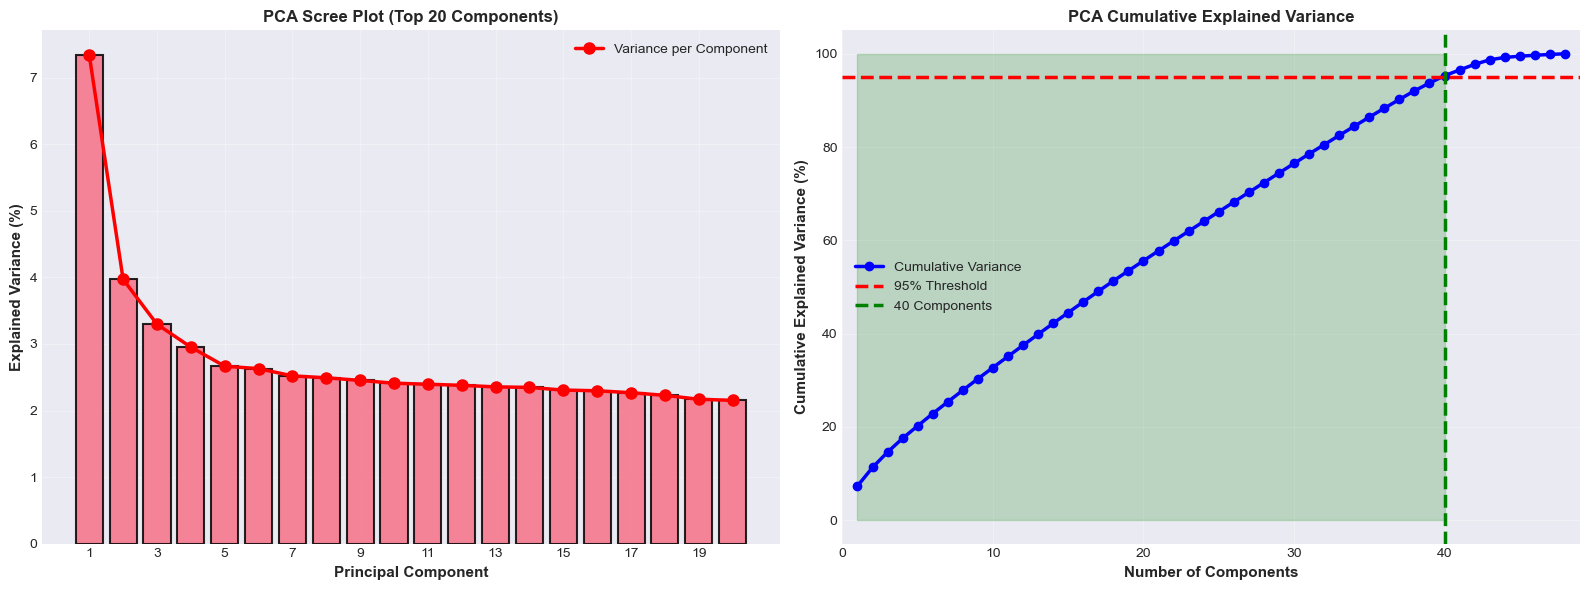


📊 SCREE PLOT INTERPRETATION:
  • Look for the 'elbow' where variance drops sharply
  • Components after the elbow add diminishing value
  • In our case, first 40 components are most informative
  • These 40 PCs capture 95.3% of total variance


In [14]:
# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot
n_show = min(20, len(explained_variance_ratio))
axes[0].bar(range(1, n_show + 1),
           explained_variance_ratio[:n_show] * 100,
           color=PALETTE[0], edgecolor='black', linewidth=1.5, alpha=0.85)
axes[0].plot(range(1, n_show + 1),
            explained_variance_ratio[:n_show] * 100,
            'ro-', linewidth=2.5, markersize=8, label='Variance per Component')
axes[0].set_xlabel('Principal Component', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Explained Variance (%)', fontweight='bold', fontsize=11)
axes[0].set_title(f'PCA Scree Plot (Top {n_show} Components)', fontweight='bold', fontsize=12)
axes[0].set_xticks(range(1, n_show + 1, max(1, n_show // 10)))
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# Cumulative variance plot
axes[1].plot(range(1, len(cumulative_variance_ratio) + 1),
            cumulative_variance_ratio * 100,
            'bo-', linewidth=2.5, markersize=6, label='Cumulative Variance')
axes[1].axhline(y=95, color='red', linestyle='--', linewidth=2.5, label='95% Threshold')
axes[1].axvline(x=n_components_95, color='green', linestyle='--', linewidth=2.5,
               label=f'{n_components_95} Components')
axes[1].fill_between(range(1, n_components_95 + 1),
                     0, 100, alpha=0.2, color='green')
axes[1].set_xlabel('Number of Components', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Cumulative Explained Variance (%)', fontweight='bold', fontsize=11)
axes[1].set_title('PCA Cumulative Explained Variance', fontweight='bold', fontsize=12)
axes[1].set_xlim(0, min(len(cumulative_variance_ratio) + 1, 50))
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n📊 SCREE PLOT INTERPRETATION:")
print(f"  • Look for the 'elbow' where variance drops sharply")
print(f"  • Components after the elbow add diminishing value")
print(f"  • In our case, first {n_components_95} components are most informative")
print(f"  • These {n_components_95} PCs capture {cumulative_variance_ratio[n_components_95-1]*100:.1f}% of total variance")


FEATURE LOADINGS ON TOP 5 PRINCIPAL COMPONENTS

Loadings show how much each feature contributes to each PC
Values near ±1 indicate strong contribution, near 0 indicates weak contribution

⚠️ Note: Showing top 10 features by absolute loading for each PC
    (Full feature set has 48 features)


PC1 Top Features:
  player_engagement_Low                    -0.430
  initial_price                            +0.404
  log_total_reviews                        +0.403
  price_tier_Premium                       +0.355
  log_ownership                            +0.334
  player_engagement_Medium                 +0.311
  days_since_release                       -0.167
  is_multiplayer_1                         +0.156
  review_score                             +0.148
  has_controller_support_1                 +0.135

PC2 Top Features:
  price_tier_Mid                           -0.525
  price_tier_Premium                       +0.455
  review_score                             -0.421
  log_total_review

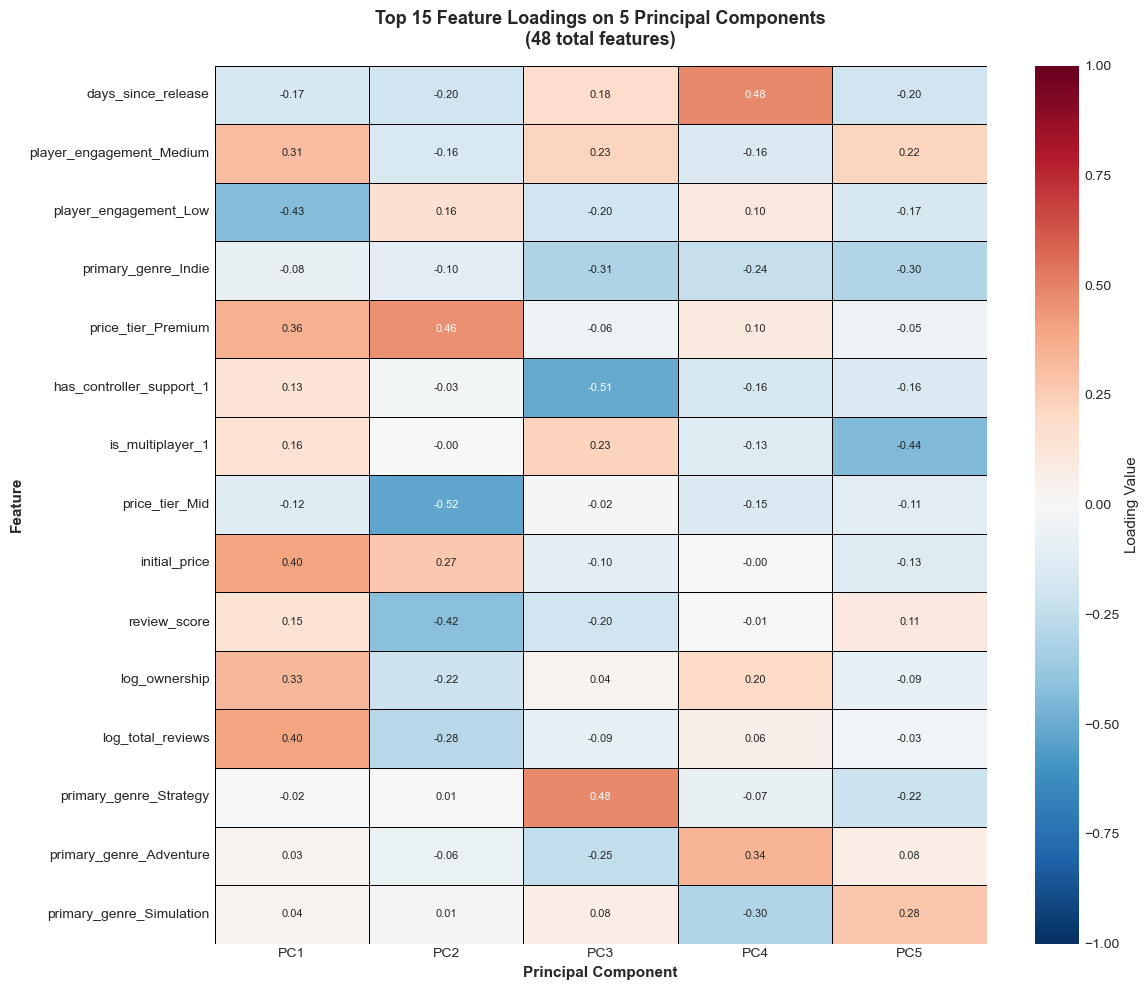


PRINCIPAL COMPONENT INTERPRETATION

PC1 (Explains 7.34% of variance):
  Top 5 Positive Contributors:
    • initial_price                                    (+0.404)
    • log_total_reviews                                (+0.403)
    • price_tier_Premium                               (+0.355)
    • log_ownership                                    (+0.334)
    • player_engagement_Medium                         (+0.311)
  Top 5 Negative Contributors:
    • player_engagement_Low                            (-0.430)
    • days_since_release                               (-0.167)
    • price_tier_Mid                                   (-0.118)
    • primary_genre_Casual                             (-0.111)
    • developer_tier_Mid-tier                          (-0.101)

PC2 (Explains 3.97% of variance):
  Top 5 Positive Contributors:
    • price_tier_Premium                               (+0.455)
    • initial_price                                    (+0.269)
    • player_engagement_Low      

In [15]:
# Feature loadings on principal components
n_components_show = min(5, n_components_95)

# Create loadings dataframe
loadings_df = pd.DataFrame(
    pca_full.components_[:n_components_show].T,
    columns=[f'PC{i+1}' for i in range(n_components_show)],
    index=pca_features
)

print("\n" + "="*80)
print(f"FEATURE LOADINGS ON TOP {n_components_show} PRINCIPAL COMPONENTS")
print("="*80)
print("\nLoadings show how much each feature contributes to each PC")
print("Values near ±1 indicate strong contribution, near 0 indicates weak contribution\n")

# For large feature sets, only show top contributors in table
if len(pca_features) > 20:
    print(f"⚠️ Note: Showing top 10 features by absolute loading for each PC")
    print(f"    (Full feature set has {len(pca_features)} features)\n")
    
    for i in range(n_components_show):
        print(f"\nPC{i+1} Top Features:")
        pc_loadings = loadings_df.iloc[:, i].abs().sort_values(ascending=False).head(10)
        for feature in pc_loadings.index:
            loading = loadings_df.loc[feature, f'PC{i+1}']
            print(f"  {feature:40} {loading:+.3f}")
else:
    # Show full table for smaller feature sets
    print(loadings_df.round(3))

# Visualize loadings as heatmap
# For large feature sets, show only top contributors
if len(pca_features) > 30:
    # Get top 15 features by total absolute loading across all shown PCs
    total_loading = loadings_df.abs().sum(axis=1).sort_values(ascending=False)
    top_features = total_loading.head(15).index
    loadings_to_plot = loadings_df.loc[top_features]
    
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(loadings_to_plot, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
               cbar_kws={'label': 'Loading Value'},
               linewidths=0.5, linecolor='black',
               vmin=-1, vmax=1, ax=ax, annot_kws={'fontsize': 8})
    ax.set_title(f'Top 15 Feature Loadings on {n_components_show} Principal Components\n({len(pca_features)} total features)',
                fontweight='bold', fontsize=13, pad=15)
else:
    # Show all features for smaller sets
    fig, ax = plt.subplots(figsize=(10, max(8, len(pca_features) * 0.3)))
    sns.heatmap(loadings_df, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
               cbar_kws={'label': 'Loading Value'},
               linewidths=0.5, linecolor='black',
               vmin=-1, vmax=1, ax=ax)
    ax.set_title(f'Feature Loadings on Top {n_components_show} Principal Components',
                fontweight='bold', fontsize=13, pad=15)

ax.set_xlabel('Principal Component', fontweight='bold', fontsize=11)
ax.set_ylabel('Feature', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

# Interpret principal components
print(f"\n" + "="*80)
print("PRINCIPAL COMPONENT INTERPRETATION")
print("="*80)

for i in range(n_components_show):
    print(f"\nPC{i+1} (Explains {explained_variance_ratio[i]*100:.2f}% of variance):")
    
    # Get top 5 positive and negative loadings (more for larger sets)
    pc_loadings = loadings_df.iloc[:, i]
    n_show = 5 if len(pca_features) > 20 else 3
    top_positive = pc_loadings.nlargest(n_show)
    top_negative = pc_loadings.nsmallest(n_show)
    
    print(f"  Top {n_show} Positive Contributors:")
    for feature, loading in top_positive.items():
        # Truncate long feature names
        feature_display = feature[:45] + "..." if len(feature) > 45 else feature
        print(f"    • {feature_display:48} ({loading:+.3f})")
    
    if abs(top_negative.iloc[0]) > 0.2:  # Lower threshold for larger sets
        print(f"  Top {n_show} Negative Contributors:")
        for feature, loading in top_negative.items():
            feature_display = feature[:45] + "..." if len(feature) > 45 else feature
            print(f"    • {feature_display:48} ({loading:+.3f})")

print(f"\n📊 HOW TO INTERPRET LOADINGS:")
print(f"  • High positive loading: feature increases as PC increases")
print(f"  • High negative loading: feature decreases as PC increases")
print(f"  • Loading near 0: feature doesn't contribute to this PC")
print(f"  • PCs are orthogonal (uncorrelated) by construction")

if len(pca_features) > 20:
    print(f"\n💡 INSIGHT FOR {len(pca_features)} FEATURES:")
    print(f"  • One-hot encoded categoricals create many binary features")
    print(f"  • PCA shows which genre/tier combinations drive variance")
    print(f"  • Example: 'primary_genre_Action' high loading = Action games vary strongly on this PC")
    print(f"  • Numeric features (price, ownership) typically dominate early PCs")

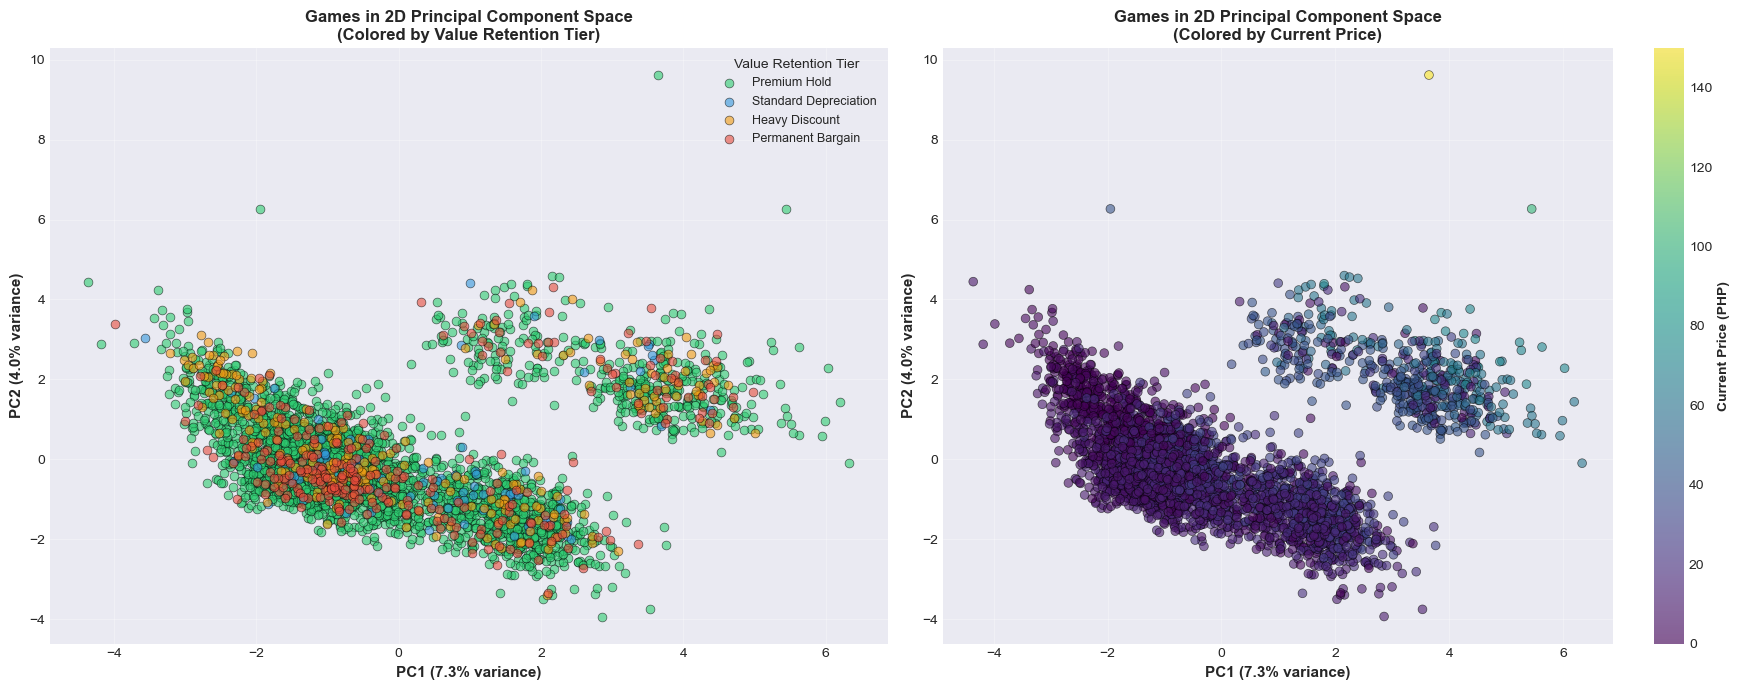


📊 2D PC SPACE INTERPRETATION:
  • Each point represents one game
  • Position determined by game's feature values
  • Similar games cluster together
  • Left plot: Check if retention tiers separate in PC space
  • Right plot: Check if price correlates with PC position
  • Clear separation suggests PCA captures meaningful patterns


In [16]:
# 2D visualization of games in PC space
# Get target variables for coloring
y_tiers = df.loc[X_pca.index, 'value_retention_tier']
y_price = df.loc[X_pca.index, 'current_price']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Colored by value retention tier
tier_order = ['Premium Hold', 'Standard Depreciation', 'Heavy Discount', 'Permanent Bargain']
tier_order = [t for t in tier_order if t in y_tiers.unique()]

for tier in tier_order:
    mask = y_tiers == tier
    color = TIER_COLORS.get(tier, PALETTE[0])
    axes[0].scatter(X_pca_transformed[mask, 0], X_pca_transformed[mask, 1],
                   c=color, label=tier, alpha=0.6, s=40, 
                   edgecolors='black', linewidths=0.5)

axes[0].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}% variance)',
                  fontweight='bold', fontsize=11)
axes[0].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}% variance)',
                  fontweight='bold', fontsize=11)
axes[0].set_title('Games in 2D Principal Component Space\n(Colored by Value Retention Tier)',
                 fontweight='bold', fontsize=12)
axes[0].legend(title='Value Retention Tier', fontsize=9, title_fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Colored by current price
scatter = axes[1].scatter(X_pca_transformed[:, 0], X_pca_transformed[:, 1],
                         c=y_price, cmap='viridis', alpha=0.6, s=40,
                         edgecolors='black', linewidths=0.5)
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('Current Price (PHP)', fontweight='bold', fontsize=10)

axes[1].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}% variance)',
                  fontweight='bold', fontsize=11)
axes[1].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}% variance)',
                  fontweight='bold', fontsize=11)
axes[1].set_title('Games in 2D Principal Component Space\n(Colored by Current Price)',
                 fontweight='bold', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 2D PC SPACE INTERPRETATION:")
print(f"  • Each point represents one game")
print(f"  • Position determined by game's feature values")
print(f"  • Similar games cluster together")
print(f"  • Left plot: Check if retention tiers separate in PC space")
print(f"  • Right plot: Check if price correlates with PC position")
print(f"  • Clear separation suggests PCA captures meaningful patterns")

---
## 3. Target Variable Analysis
---

We examine both modeling targets:
- **Regression:** `current_price` (PHP) — continuous price prediction
- **Classification:** `value_retention_tier` — categorical price retention behavior

### Why these targets matter:
- `current_price` tells us **what** a game sells for today
- `value_retention_tier` tells us **how** a game's pricing strategy behaves over time
- Together, they capture both absolute pricing and relative depreciation patterns

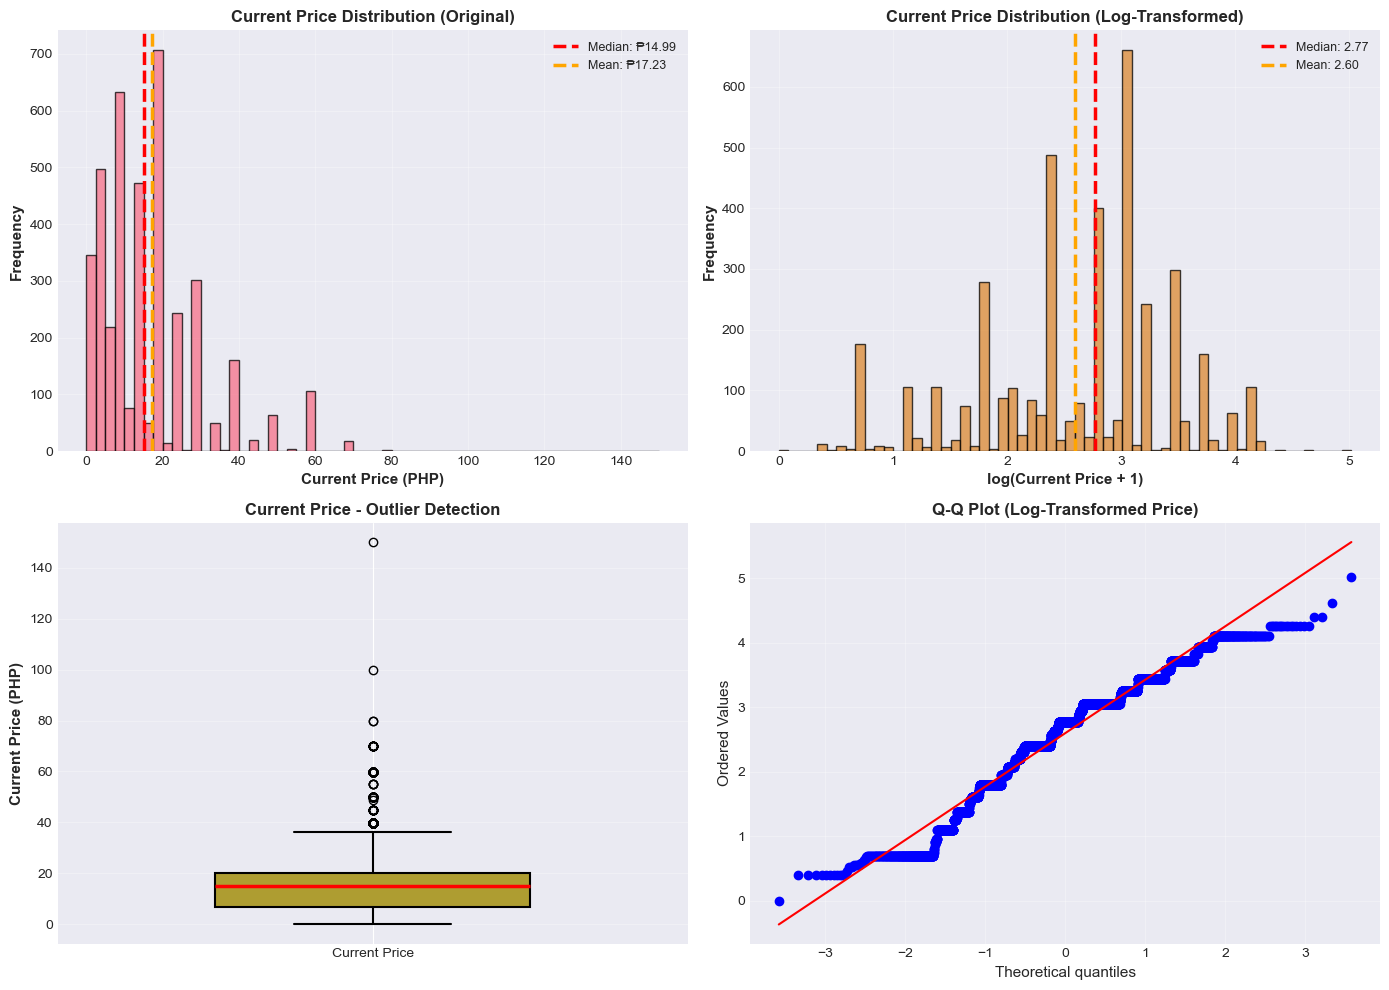

REGRESSION TARGET: CURRENT_PRICE

Descriptive Statistics:
  Count:      3,987
  Mean:       ₱17.23
  Median:     ₱14.99
  Std Dev:    ₱13.88
  Min:        ₱0.00
  Max:        ₱149.99
  Q1 (25%):   ₱6.99
  Q3 (75%):   ₱19.99

Distribution Shape:
  Skewness:   1.587
  Kurtosis:   4.209

Outliers (IQR method):
  Count:      373 (9.4%)
  Range:      ₱39.64 - ₱149.99

📊 INTERPRETATION:
  • Distribution is HIGHLY RIGHT-SKEWED (skewness = 1.59)
  • Most games are budget-priced, with a long tail of premium titles
  • RECOMMENDATION: Apply log transformation for regression models


In [18]:
# === REGRESSION TARGET: current_price ===

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original distribution
price_data = df['current_price'].dropna()
axes[0, 0].hist(price_data, bins=60, edgecolor='black', alpha=0.75, color=PALETTE[0])
axes[0, 0].axvline(price_data.median(), color='red', linestyle='--', linewidth=2.5, 
                   label=f'Median: ₱{price_data.median():.2f}')
axes[0, 0].axvline(price_data.mean(), color='orange', linestyle='--', linewidth=2.5,
                   label=f'Mean: ₱{price_data.mean():.2f}')
axes[0, 0].set_xlabel('Current Price (PHP)', fontweight='bold', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontweight='bold', fontsize=11)
axes[0, 0].set_title('Current Price Distribution (Original)', fontweight='bold', fontsize=12)
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

# Log transformation
log_price = np.log1p(price_data)
axes[0, 1].hist(log_price, bins=60, edgecolor='black', alpha=0.75, color=PALETTE[1])
axes[0, 1].axvline(log_price.median(), color='red', linestyle='--', linewidth=2.5,
                   label=f'Median: {log_price.median():.2f}')
axes[0, 1].axvline(log_price.mean(), color='orange', linestyle='--', linewidth=2.5,
                   label=f'Mean: {log_price.mean():.2f}')
axes[0, 1].set_xlabel('log(Current Price + 1)', fontweight='bold', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontweight='bold', fontsize=11)
axes[0, 1].set_title('Current Price Distribution (Log-Transformed)', fontweight='bold', fontsize=12)
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

# Box plot for outlier detection
bp = axes[1, 0].boxplot(price_data, vert=True, patch_artist=True, widths=0.5,
                        boxprops=dict(facecolor=PALETTE[2], edgecolor='black', linewidth=1.5),
                        medianprops=dict(color='red', linewidth=2.5),
                        whiskerprops=dict(color='black', linewidth=1.5),
                        capprops=dict(color='black', linewidth=1.5))
axes[1, 0].set_ylabel('Current Price (PHP)', fontweight='bold', fontsize=11)
axes[1, 0].set_title('Current Price - Outlier Detection', fontweight='bold', fontsize=12)
axes[1, 0].set_xticklabels(['Current Price'])
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Q-Q plot for normality assessment
stats.probplot(log_price, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Log-Transformed Price)', fontweight='bold', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print("="*80)
print("REGRESSION TARGET: CURRENT_PRICE")
print("="*80)
print(f"\nDescriptive Statistics:")
print(f"  Count:      {len(price_data):,}")
print(f"  Mean:       ₱{price_data.mean():.2f}")
print(f"  Median:     ₱{price_data.median():.2f}")
print(f"  Std Dev:    ₱{price_data.std():.2f}")
print(f"  Min:        ₱{price_data.min():.2f}")
print(f"  Max:        ₱{price_data.max():.2f}")
print(f"  Q1 (25%):   ₱{price_data.quantile(0.25):.2f}")
print(f"  Q3 (75%):   ₱{price_data.quantile(0.75):.2f}")

print(f"\nDistribution Shape:")
print(f"  Skewness:   {price_data.skew():.3f}")
print(f"  Kurtosis:   {price_data.kurtosis():.3f}")

# Outlier analysis
Q1 = price_data.quantile(0.25)
Q3 = price_data.quantile(0.75)
IQR = Q3 - Q1
outliers = price_data[(price_data < Q1 - 1.5*IQR) | (price_data > Q3 + 1.5*IQR)]
print(f"\nOutliers (IQR method):")
print(f"  Count:      {len(outliers):,} ({len(outliers)/len(price_data)*100:.1f}%)")
if len(outliers) > 0:
    print(f"  Range:      ₱{outliers.min():.2f} - ₱{outliers.max():.2f}")

print(f"\n📊 INTERPRETATION:")
if price_data.skew() > 1:
    print(f"  • Distribution is HIGHLY RIGHT-SKEWED (skewness = {price_data.skew():.2f})")
    print(f"  • Most games are budget-priced, with a long tail of premium titles")
    print(f"  • RECOMMENDATION: Apply log transformation for regression models")
elif price_data.skew() > 0.5:
    print(f"  • Distribution is MODERATELY RIGHT-SKEWED (skewness = {price_data.skew():.2f})")
    print(f"  • Consider log transformation to normalize distribution")
else:
    print(f"  • Distribution is approximately symmetric (skewness = {price_data.skew():.2f})")
    print(f"  • Standard scaling should be sufficient")

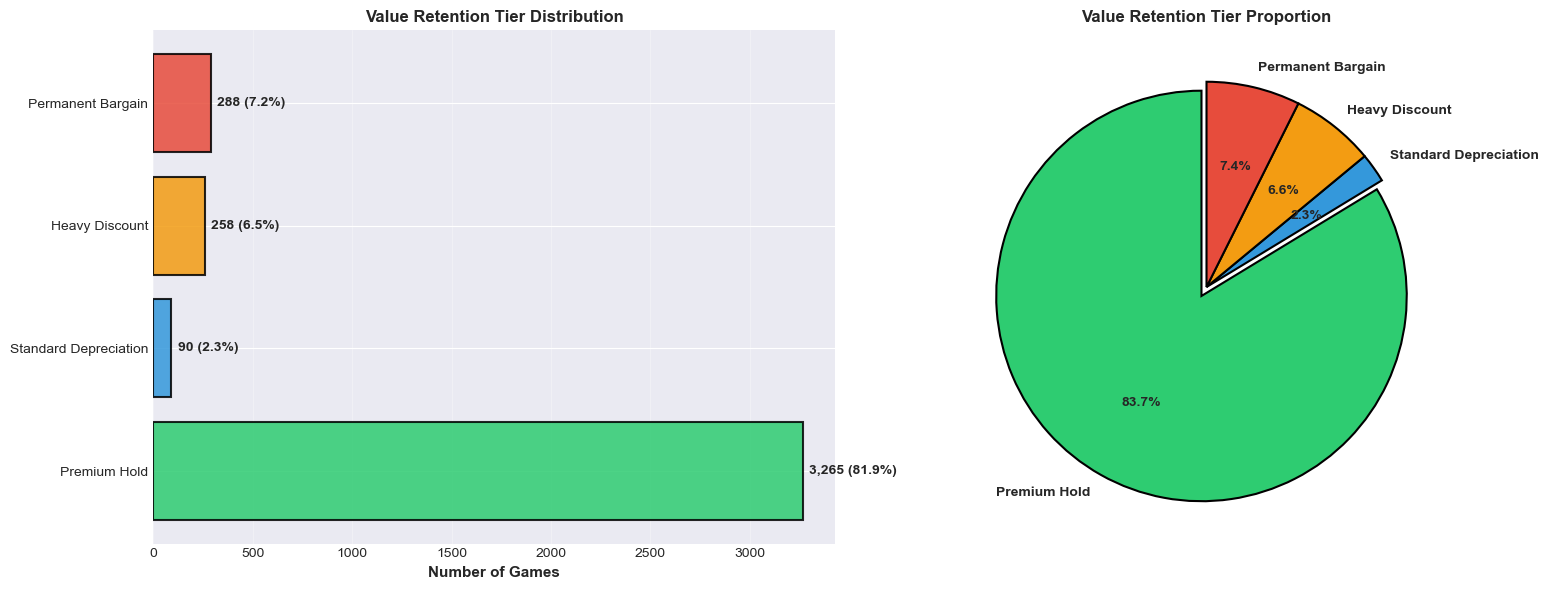


CLASSIFICATION TARGET: VALUE_RETENTION_TIER

Class Distribution:
  Premium Hold               3,265 (81.89%)
  Standard Depreciation         90 ( 2.26%)
  Heavy Discount               258 ( 6.47%)
  Permanent Bargain            288 ( 7.22%)

Class Imbalance Analysis:
  Largest class:  Premium Hold (3,265 samples)
  Smallest class: Too New (86 samples)
  Imbalance ratio: 37.97:1

📊 INTERPRETATION:
  ⚠️ SEVERE CLASS IMBALANCE DETECTED!
  • Imbalance ratio of 38.0:1 will cause model bias
  • REQUIRED: Use SMOTE (Synthetic Minority Over-sampling) or class_weight='balanced'
  • Models will likely predict majority class by default without balancing

✅ RECOMMENDATIONS FOR PHASE 4:
  • Use stratified train/test split (stratify=y parameter)
  • Use stratified k-fold cross-validation (StratifiedKFold)
  • Set class_weight='balanced' in all sklearn classifiers
  • Alternatively, apply SMOTE to training data only
  • Evaluate with F1-score and per-class precision/recall, not just accuracy


In [19]:
# === CLASSIFICATION TARGET: value_retention_tier ===

# Distribution analysis
tier_counts = df['value_retention_tier'].value_counts()
tier_pcts = (tier_counts / len(df) * 100).round(2)

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot with counts
tier_order = ['Premium Hold', 'Standard Depreciation', 'Heavy Discount', 'Permanent Bargain']
tier_order = [t for t in tier_order if t in tier_counts.index]  # Keep only existing tiers

y_pos = np.arange(len(tier_order))
counts = [tier_counts.get(t, 0) for t in tier_order]
colors = [TIER_COLORS.get(t, PALETTE[i]) for i, t in enumerate(tier_order)]

bars = axes[0].barh(y_pos, counts, color=colors, edgecolor='black', linewidth=1.5, alpha=0.85)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(tier_order)
axes[0].set_xlabel('Number of Games', fontweight='bold', fontsize=11)
axes[0].set_title('Value Retention Tier Distribution', fontweight='bold', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='x')

# Add count and percentage labels
for i, (bar, count) in enumerate(zip(bars, counts)):
    pct = tier_pcts.get(tier_order[i], 0)
    axes[0].text(count + max(counts)*0.01, i, 
                f'{count:,} ({pct:.1f}%)',
                va='center', fontweight='bold', fontsize=10)

# Pie chart
explode = [0.05 if i == 0 else 0 for i in range(len(tier_order))]
wedges, texts, autotexts = axes[1].pie(counts, labels=tier_order, autopct='%1.1f%%',
                                       startangle=90, colors=colors, explode=explode,
                                       wedgeprops={'edgecolor': 'black', 'linewidth': 1.5},
                                       textprops={'fontsize': 10, 'fontweight': 'bold'})
axes[1].set_title('Value Retention Tier Proportion', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# Statistics
print("\n" + "="*80)
print("CLASSIFICATION TARGET: VALUE_RETENTION_TIER")
print("="*80)

print(f"\nClass Distribution:")
for tier in tier_order:
    count = tier_counts.get(tier, 0)
    pct = tier_pcts.get(tier, 0)
    print(f"  {tier:25} {count:6,} ({pct:5.2f}%)")

# Class imbalance analysis
max_class = tier_counts.max()
min_class = tier_counts.min()
imbalance_ratio = max_class / min_class if min_class > 0 else np.inf

print(f"\nClass Imbalance Analysis:")
print(f"  Largest class:  {tier_counts.idxmax()} ({max_class:,} samples)")
print(f"  Smallest class: {tier_counts.idxmin()} ({min_class:,} samples)")
print(f"  Imbalance ratio: {imbalance_ratio:.2f}:1")

print(f"\n📊 INTERPRETATION:")
if imbalance_ratio > 10:
    print(f"  ⚠️ SEVERE CLASS IMBALANCE DETECTED!")
    print(f"  • Imbalance ratio of {imbalance_ratio:.1f}:1 will cause model bias")
    print(f"  • REQUIRED: Use SMOTE (Synthetic Minority Over-sampling) or class_weight='balanced'")
    print(f"  • Models will likely predict majority class by default without balancing")
elif imbalance_ratio > 3:
    print(f"  ⚠️ MODERATE CLASS IMBALANCE DETECTED")
    print(f"  • Imbalance ratio of {imbalance_ratio:.1f}:1 may affect model performance")
    print(f"  • RECOMMENDED: Use class_weight='balanced' in sklearn models")
    print(f"  • Consider stratified sampling in train/test split")
else:
    print(f"  ✓ Classes are relatively balanced (ratio {imbalance_ratio:.1f}:1)")
    print(f"  • Standard training procedures should work well")

print(f"\n✅ RECOMMENDATIONS FOR PHASE 4:")
print(f"  • Use stratified train/test split (stratify=y parameter)")
print(f"  • Use stratified k-fold cross-validation (StratifiedKFold)")
if imbalance_ratio > 3:
    print(f"  • Set class_weight='balanced' in all sklearn classifiers")
    print(f"  • Alternatively, apply SMOTE to training data only")
print(f"  • Evaluate with F1-score and per-class precision/recall, not just accuracy")


PROPORTIONAL CHANCE CRITERION (PCC) - BASELINE ACCURACY METRIC

Class Distribution (n=3,987 games):

Class                               Count   Proportion           p²
--------------------------------------------------------------------------------
Premium Hold                        3,265      0.8189      0.6706
Permanent Bargain                     288      0.0722      0.0052
Heavy Discount                        258      0.0647      0.0042
Standard Depreciation                  90      0.0226      0.0005
Too New                                86      0.0216      0.0005

PCC FORMULA: Σ(p_i²)

PCC = (0.8189)² + (0.0722)² + (0.0647)² + (0.0226)² + (0.0216)²
    = 0.670616 + 0.005218 + 0.004187 + 0.000510 + 0.000465
    = 0.680996

PCC BASELINE ACCURACY: 68.10%

📊 WHAT IS PCC?

The Proportional Chance Criterion represents the expected accuracy of a
NAIVE CLASSIFIER that randomly assigns classes proportional to their distribution.

Example: If 60% of games are 'Premium Hold', the naive

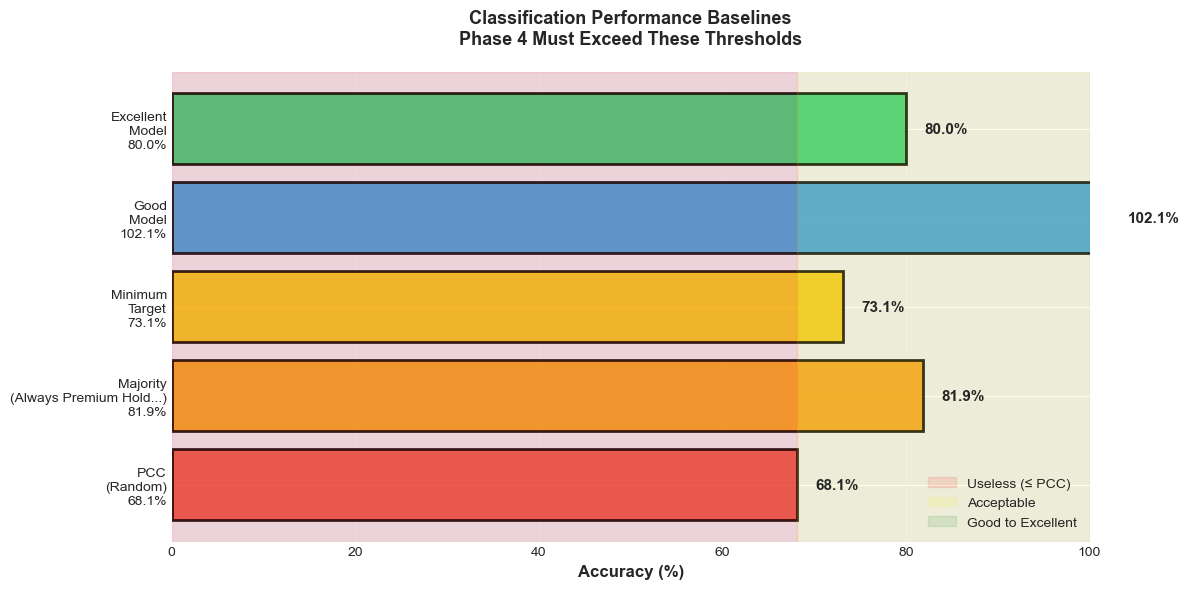


✅ PCC calculated: 68.10%
   Phase 4 classifier must exceed this baseline to be useful!


In [20]:
# === PROPORTIONAL CHANCE CRITERION (PCC) - Classification Baseline ===

print("\n" + "="*80)
print("PROPORTIONAL CHANCE CRITERION (PCC) - BASELINE ACCURACY METRIC")
print("="*80)

# Get class distribution
tier_counts = df['value_retention_tier'].value_counts()
tier_props = tier_counts / len(df)

print(f"\nClass Distribution (n={len(df):,} games):")
print(f"\n{'Class':<30} {'Count':>10} {'Proportion':>12} {'p²':>12}")
print("-"*80)
for tier in tier_counts.index:
    count = tier_counts[tier]
    prop = tier_props[tier]
    prop_sq = prop ** 2
    print(f"{tier:<30} {count:>10,} {prop:>11.4f} {prop_sq:>11.4f}")

# Calculate PCC: Sum of squared proportions
pcc = (tier_props ** 2).sum()
pcc_pct = pcc * 100

print(f"\n" + "="*80)
print(f"PCC FORMULA: Σ(p_i²)")
print("="*80)
terms = ' + '.join([f"({p:.4f})²" for p in tier_props.values])
values = ' + '.join([f"{p**2:.6f}" for p in tier_props.values])
print(f"\nPCC = {terms}")
print(f"    = {values}")
print(f"    = {pcc:.6f}")
print(f"\n" + "="*80)
print(f"PCC BASELINE ACCURACY: {pcc_pct:.2f}%")
print("="*80)

# Explanation
print(f"\n📊 WHAT IS PCC?")
print(f"\nThe Proportional Chance Criterion represents the expected accuracy of a")
print(f"NAIVE CLASSIFIER that randomly assigns classes proportional to their distribution.")
print(f"\nExample: If 60% of games are 'Premium Hold', the naive classifier predicts")
print(f"         'Premium Hold' 60% of the time (randomly), achieving ~60% accuracy")
print(f"         just by chance.")

print(f"\n⚠️ CRITICAL IMPLICATION:")
print(f"   Any model with accuracy ≤ {pcc_pct:.2f}% is NO BETTER than random guessing!")

# Compare with majority class baseline
majority_class = tier_props.idxmax()
majority_acc = tier_props.max() * 100

print(f"\n📌 BASELINE COMPARISON:")
print(f"   • PCC (proportional random):        {pcc_pct:>6.2f}%")
print(f"   • Majority class baseline:          {majority_acc:>6.2f}%")
print(f"     (Always predict '{majority_class}')")

# Set Phase 4 targets
min_target = pcc_pct + 5  # At least 5% above PCC
good_target = max(pcc_pct * 1.5, 70)  # 50% better than PCC, or 70%
excellent_target = 80

print(f"\n🎯 PHASE 4 PERFORMANCE TARGETS:")
print(f"   • Minimum (beats PCC):       > {min_target:.1f}%")
print(f"   • Good model:                ≥ {good_target:.1f}%")
print(f"   • Excellent model:           ≥ {excellent_target:.1f}%")

print(f"\n⚠️ WARNING ABOUT ACCURACY:")
print(f"   With imbalanced classes, accuracy is MISLEADING!")
print(f"   \n   Example: A model that always predicts '{majority_class}' gets")
print(f"            {majority_acc:.1f}% accuracy but is COMPLETELY USELESS.")
print(f"\n   ✅ SOLUTION: Use balanced metrics:")
print(f"      • F1-score (macro average)")
print(f"      • Per-class Precision & Recall")
print(f"      • Confusion Matrix")
print(f"      • ROC-AUC (if applicable)")

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

baseline_names = [
    f'PCC\n(Random)\n{pcc_pct:.1f}%',
    f'Majority\n(Always {majority_class[:15]}...)\n{majority_acc:.1f}%',
    f'Minimum\nTarget\n{min_target:.1f}%',
    f'Good\nModel\n{good_target:.1f}%',
    f'Excellent\nModel\n{excellent_target:.1f}%'
]
baseline_values = [pcc_pct, majority_acc, min_target, good_target, excellent_target]
colors = ['#e74c3c', '#f39c12', '#f1c40f', '#3498db', '#2ecc71']

bars = ax.barh(baseline_names, baseline_values, color=colors, 
              edgecolor='black', linewidth=2, alpha=0.85)

ax.set_xlabel('Accuracy (%)', fontweight='bold', fontsize=12)
ax.set_title('Classification Performance Baselines\nPhase 4 Must Exceed These Thresholds',
            fontweight='bold', fontsize=13, pad=20)
ax.set_xlim(0, 100)
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, val in zip(bars, baseline_values):
    width = bar.get_width()
    ax.text(width + 2, bar.get_y() + bar.get_height()/2, 
           f'{val:.1f}%', va='center', fontweight='bold', fontsize=11)

# Add zone annotations
ax.axvspan(0, pcc_pct, alpha=0.1, color='red', label='Useless (≤ PCC)')
ax.axvspan(pcc_pct, good_target, alpha=0.1, color='yellow', label='Acceptable')
ax.axvspan(good_target, 100, alpha=0.1, color='green', label='Good to Excellent')
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n✅ PCC calculated: {pcc_pct:.2f}%")
print(f"   Phase 4 classifier must exceed this baseline to be useful!")

---
## 4. Feature Distribution Analysis
---

Examining the distribution of key features that will be used in ML models.

**Why this matters:**
- Identifies need for transformations (log, power, etc.)
- Detects outliers that may require handling
- Reveals skewness that affects model assumptions
- Informs scaling strategy (StandardScaler vs RobustScaler)

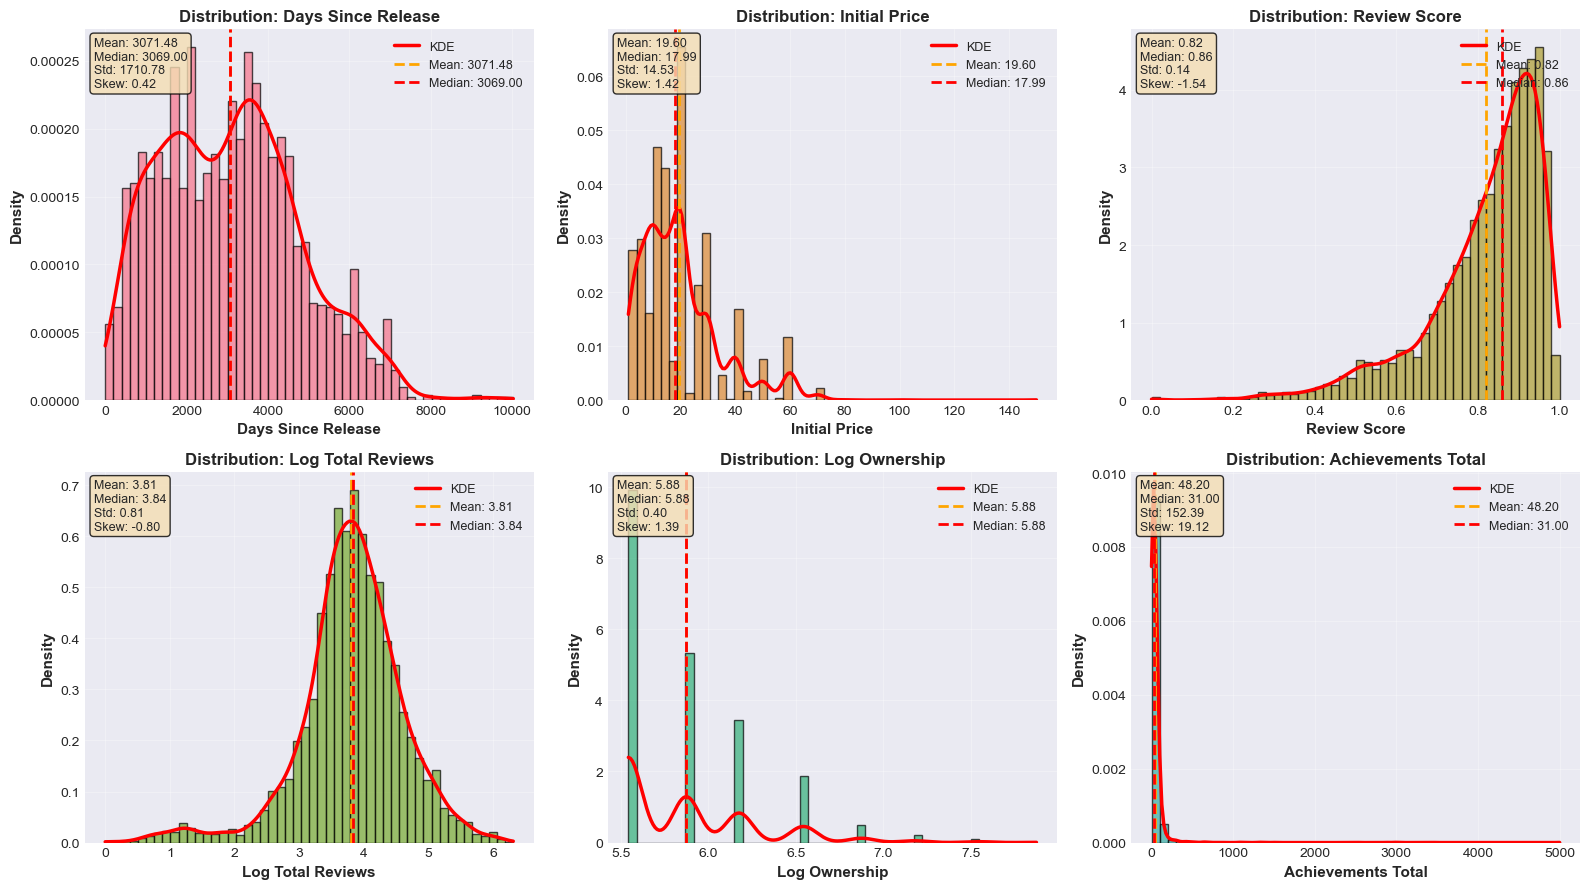


NUMERICAL FEATURES - DISTRIBUTION SUMMARY

days_since_release:
  Range: [-1.00, 10028.00]
  Mean ± Std: 3071.48 ± 1710.78
  Skewness: 0.425 (approximately symmetric)

initial_price:
  Range: [0.99, 149.99]
  Mean ± Std: 19.60 ± 14.53
  Skewness: 1.424 (HIGHLY SKEWED - consider log/sqrt transformation)

review_score:
  Range: [0.00, 1.00]
  Mean ± Std: 0.82 ± 0.14
  Skewness: -1.540 (HIGHLY SKEWED - consider log/sqrt transformation)

log_total_reviews:
  Range: [0.00, 6.31]
  Mean ± Std: 3.81 ± 0.81
  Skewness: -0.798 (MODERATELY SKEWED - transformation may help)

log_ownership:
  Range: [5.54, 7.88]
  Mean ± Std: 5.88 ± 0.40
  Skewness: 1.389 (HIGHLY SKEWED - consider log/sqrt transformation)

achievements_total:
  Range: [0.00, 5000.00]
  Mean ± Std: 48.20 ± 152.39
  Skewness: 19.118 (HIGHLY SKEWED - consider log/sqrt transformation)


In [22]:
# Distribution plots for numerical features
n_features = len(numeric_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4.5))
axes = axes.ravel() if n_features > 1 else [axes]

for idx, feature in enumerate(numeric_features):
    data = df[feature].dropna()
    
    # Histogram with KDE
    axes[idx].hist(data, bins=50, edgecolor='black', alpha=0.7, 
                   color=PALETTE[idx % len(PALETTE)], density=True)
    
    # Add KDE curve
    if len(data) > 1 and data.std() > 0:
        kde = gaussian_kde(data)
        x_range = np.linspace(data.min(), data.max(), 200)
        axes[idx].plot(x_range, kde(x_range), 'r-', linewidth=2.5, label='KDE')
    
    # Add mean and median lines
    axes[idx].axvline(data.mean(), color='orange', linestyle='--', linewidth=2,
                     label=f'Mean: {data.mean():.2f}')
    axes[idx].axvline(data.median(), color='red', linestyle='--', linewidth=2,
                     label=f'Median: {data.median():.2f}')
    
    axes[idx].set_xlabel(feature.replace('_', ' ').title(), fontweight='bold', fontsize=11)
    axes[idx].set_ylabel('Density', fontweight='bold', fontsize=11)
    axes[idx].set_title(f'Distribution: {feature.replace("_", " ").title()}',
                       fontweight='bold', fontsize=12)
    axes[idx].legend(fontsize=9, loc='upper right')
    axes[idx].grid(True, alpha=0.3)
    
    # Add statistics text box
    stats_text = (
        f"Mean: {data.mean():.2f}\n"
        f"Median: {data.median():.2f}\n"
        f"Std: {data.std():.2f}\n"
        f"Skew: {data.skew():.2f}"
    )
    axes[idx].text(0.02, 0.98, stats_text, transform=axes[idx].transAxes,
                  fontsize=9, verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Hide unused subplots
for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# Print distribution summary
print("\n" + "="*80)
print("NUMERICAL FEATURES - DISTRIBUTION SUMMARY")
print("="*80)

for feature in numeric_features:
    data = df[feature].dropna()
    print(f"\n{feature}:")
    print(f"  Range: [{data.min():.2f}, {data.max():.2f}]")
    print(f"  Mean ± Std: {data.mean():.2f} ± {data.std():.2f}")
    print(f"  Skewness: {data.skew():.3f}", end="")
    
    if abs(data.skew()) > 1:
        print(f" (HIGHLY SKEWED - consider log/sqrt transformation)")
    elif abs(data.skew()) > 0.5:
        print(f" (MODERATELY SKEWED - transformation may help)")
    else:
        print(f" (approximately symmetric)")

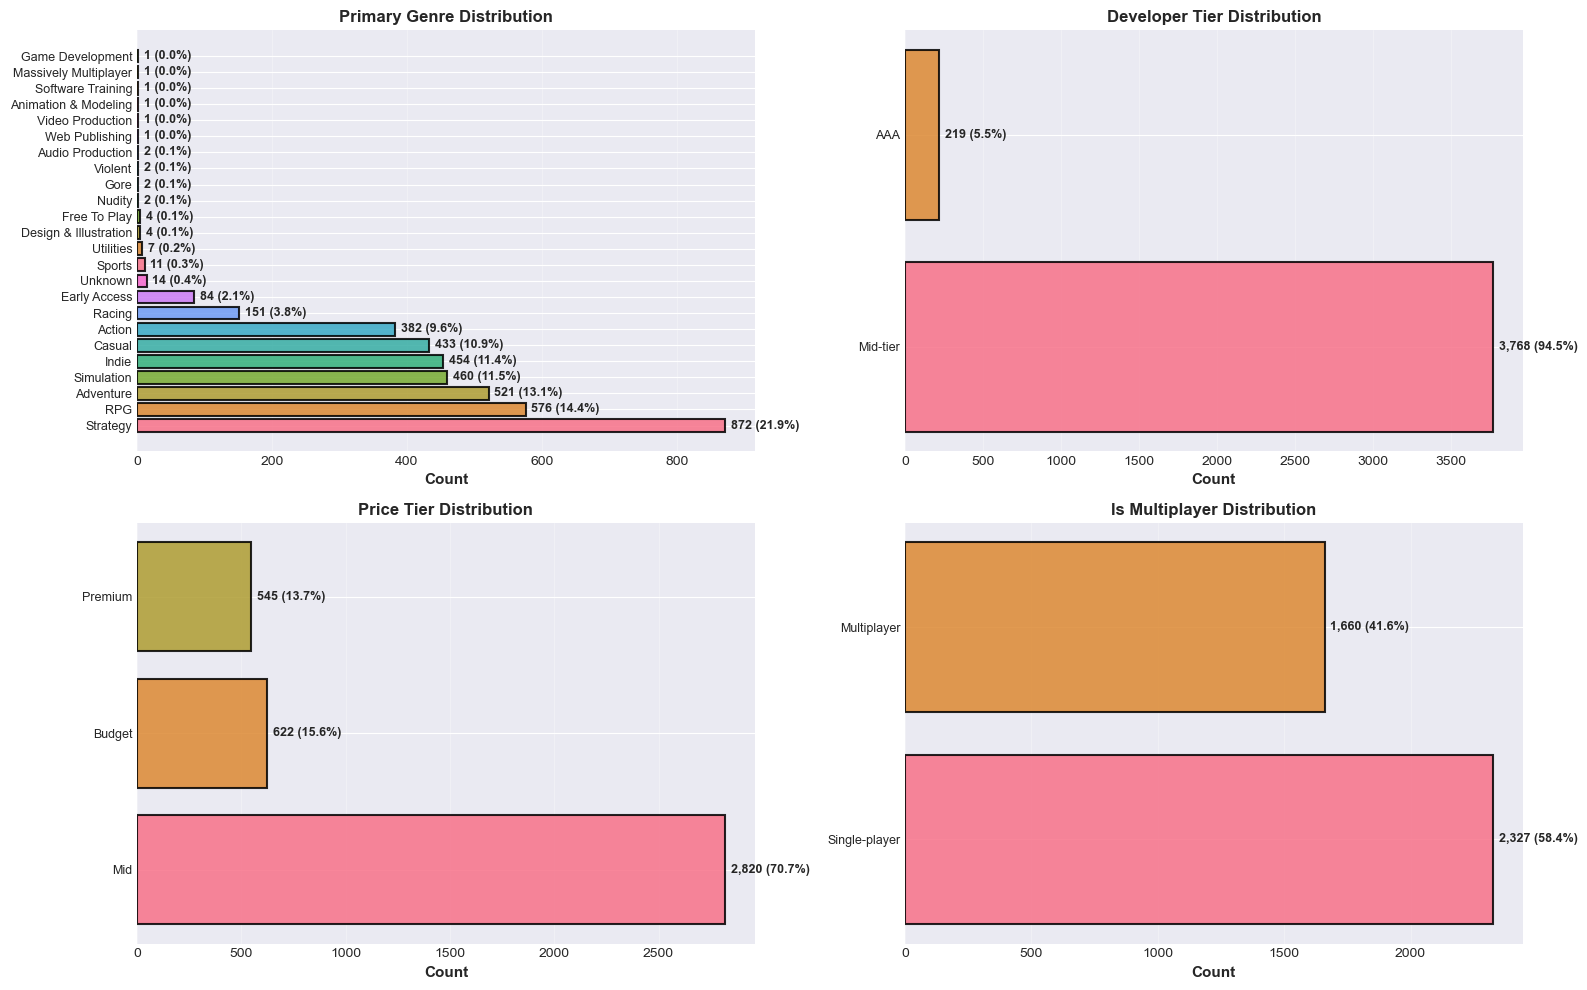


CATEGORICAL FEATURES - SUMMARY

primary_genre:
  Unique values: 24
  Distribution:
    Strategy                872 (21.87%)
    RPG                     576 (14.45%)
    Adventure               521 (13.07%)
    Simulation              460 (11.54%)
    Indie                   454 (11.39%)
    Casual                  433 (10.86%)
    Action                  382 ( 9.58%)
    Racing                  151 ( 3.79%)
    Early Access             84 ( 2.11%)
    Unknown                  14 ( 0.35%)
    Sports                   11 ( 0.28%)
    Utilities                 7 ( 0.18%)
    Design & Illustration      4 ( 0.10%)
    Free To Play              4 ( 0.10%)
    Nudity                    2 ( 0.05%)
    Gore                      2 ( 0.05%)
    Violent                   2 ( 0.05%)
    Audio Production          2 ( 0.05%)
    Web Publishing            1 ( 0.03%)
    Video Production          1 ( 0.03%)
    Animation & Modeling      1 ( 0.03%)
    Software Training         1 ( 0.03%)
    Massively

In [23]:
# Categorical features analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

# Show first 4 categorical features
features_to_plot = categorical_features[:min(4, len(categorical_features))]

for idx, feature in enumerate(features_to_plot):
    if feature == 'is_multiplayer':
        # Convert binary to labels
        plot_data = df[feature].map({0: 'Single-player', 1: 'Multiplayer', np.nan: 'Unknown'})
    elif feature == 'has_controller_support':
        plot_data = df[feature].map({0: 'No', 1: 'Yes', np.nan: 'Unknown'})
    else:
        plot_data = df[feature].fillna('Unknown')
    
    value_counts = plot_data.value_counts()
    
    # Horizontal bar plot
    y_pos = np.arange(len(value_counts))
    colors_list = [PALETTE[i % len(PALETTE)] for i in range(len(value_counts))]
    
    bars = axes[idx].barh(y_pos, value_counts.values, color=colors_list,
                          edgecolor='black', linewidth=1.5, alpha=0.85)
    axes[idx].set_yticks(y_pos)
    axes[idx].set_yticklabels(value_counts.index, fontsize=9)
    axes[idx].set_xlabel('Count', fontweight='bold', fontsize=11)
    axes[idx].set_title(f'{feature.replace("_", " ").title()} Distribution',
                       fontweight='bold', fontsize=12)
    axes[idx].grid(True, alpha=0.3, axis='x')
    
    # Add count and percentage labels
    total = value_counts.sum()
    for i, (bar, count) in enumerate(zip(bars, value_counts.values)):
        pct = (count / total * 100)
        axes[idx].text(count + max(value_counts.values)*0.01, i,
                      f'{count:,} ({pct:.1f}%)',
                      va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Print categorical summary
print("\n" + "="*80)
print("CATEGORICAL FEATURES - SUMMARY")
print("="*80)

for feature in categorical_features:
    if feature == 'is_multiplayer':
        plot_data = df[feature].map({0: 'Single-player', 1: 'Multiplayer', np.nan: 'Unknown'})
    elif feature == 'has_controller_support':
        plot_data = df[feature].map({0: 'No', 1: 'Yes', np.nan: 'Unknown'})
    else:
        plot_data = df[feature].fillna('Unknown')
    
    value_counts = plot_data.value_counts()
    print(f"\n{feature}:")
    print(f"  Unique values: {len(value_counts)}")
    print(f"  Distribution:")
    for cat, count in value_counts.items():
        pct = count / len(df) * 100
        print(f"    {str(cat):20} {count:6,} ({pct:5.2f}%)")

---
## 5. Correlation Analysis & Multicollinearity
---

### Why This Matters:
- **Multicollinearity** (high correlation between features) can cause:
  - Unstable coefficient estimates in linear models
  - Difficulty interpreting feature importance
  - Numerical instability in model fitting
- Tree-based models (Random Forest, XGBoost) are **robust to multicollinearity**
- Linear models (Linear Regression, Logistic Regression) are **sensitive to it**

### Thresholds:
- **|r| > 0.9:** SEVERE multicollinearity — remove one feature from pair
- **|r| > 0.7:** MODERATE multicollinearity — consider removal or regularization
- **|r| < 0.7:** Generally acceptable

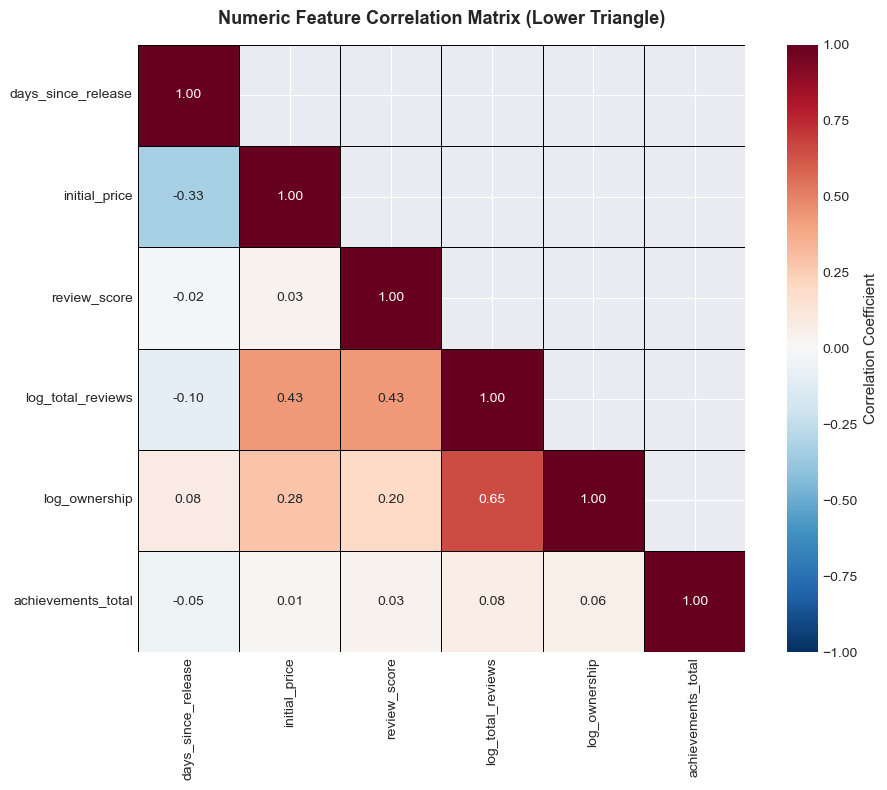

MULTICOLLINEARITY ANALYSIS

⚠️ SEVERE MULTICOLLINEARITY (|r| > 0.9):
  ✓ No severe multicollinearity detected

⚠️ MODERATE MULTICOLLINEARITY (|r| > 0.7):
  ✓ No moderate multicollinearity detected

✅ All numeric feature correlations are acceptable (|r| < 0.7)
  • Numeric features are relatively independent
  • Safe to use all features in modeling
  • Both linear and tree-based models should work well


In [25]:
# Correlation analysis on numeric features only
# (One-hot encoded features are expected to be uncorrelated)

numeric_corr_matrix = df[numeric_features].corr()

# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))

# Mask upper triangle
mask = np.triu(np.ones_like(numeric_corr_matrix, dtype=bool), k=1)

sns.heatmap(numeric_corr_matrix, mask=mask, annot=True, fmt='.2f',
           cmap='RdBu_r', center=0, vmin=-1, vmax=1,
           cbar_kws={'label': 'Correlation Coefficient'},
           linewidths=0.5, linecolor='black',
           square=True, ax=ax)

ax.set_title('Numeric Feature Correlation Matrix (Lower Triangle)',
            fontweight='bold', fontsize=13, pad=15)

plt.tight_layout()
plt.show()

# Identify highly correlated feature pairs
high_corr_pairs = []
moderate_corr_pairs = []

for i in range(len(numeric_features)):
    for j in range(i+1, len(numeric_features)):
        corr = numeric_corr_matrix.iloc[i, j]
        if abs(corr) > 0.9:
            high_corr_pairs.append((numeric_features[i], numeric_features[j], corr))
        elif abs(corr) > 0.7:
            moderate_corr_pairs.append((numeric_features[i], numeric_features[j], corr))

print("="*80)
print("MULTICOLLINEARITY ANALYSIS")
print("="*80)

print("\n⚠️ SEVERE MULTICOLLINEARITY (|r| > 0.9):")
if high_corr_pairs:
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  • {feat1:25} <-> {feat2:25} r={corr:+.3f}")
    print(f"\n  ACTION REQUIRED: Remove one feature from each pair")
else:
    print(f"  ✓ No severe multicollinearity detected")

print("\n⚠️ MODERATE MULTICOLLINEARITY (|r| > 0.7):")
if moderate_corr_pairs:
    for feat1, feat2, corr in sorted(moderate_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  • {feat1:25} <-> {feat2:25} r={corr:+.3f}")
    print(f"\n  RECOMMENDATION: Consider feature selection or use regularization (Ridge/Lasso)")
else:
    print(f"  ✓ No moderate multicollinearity detected")

if not high_corr_pairs and not moderate_corr_pairs:
    print("\n✅ All numeric feature correlations are acceptable (|r| < 0.7)")
    print("  • Numeric features are relatively independent")
    print("  • Safe to use all features in modeling")
    print("  • Both linear and tree-based models should work well")

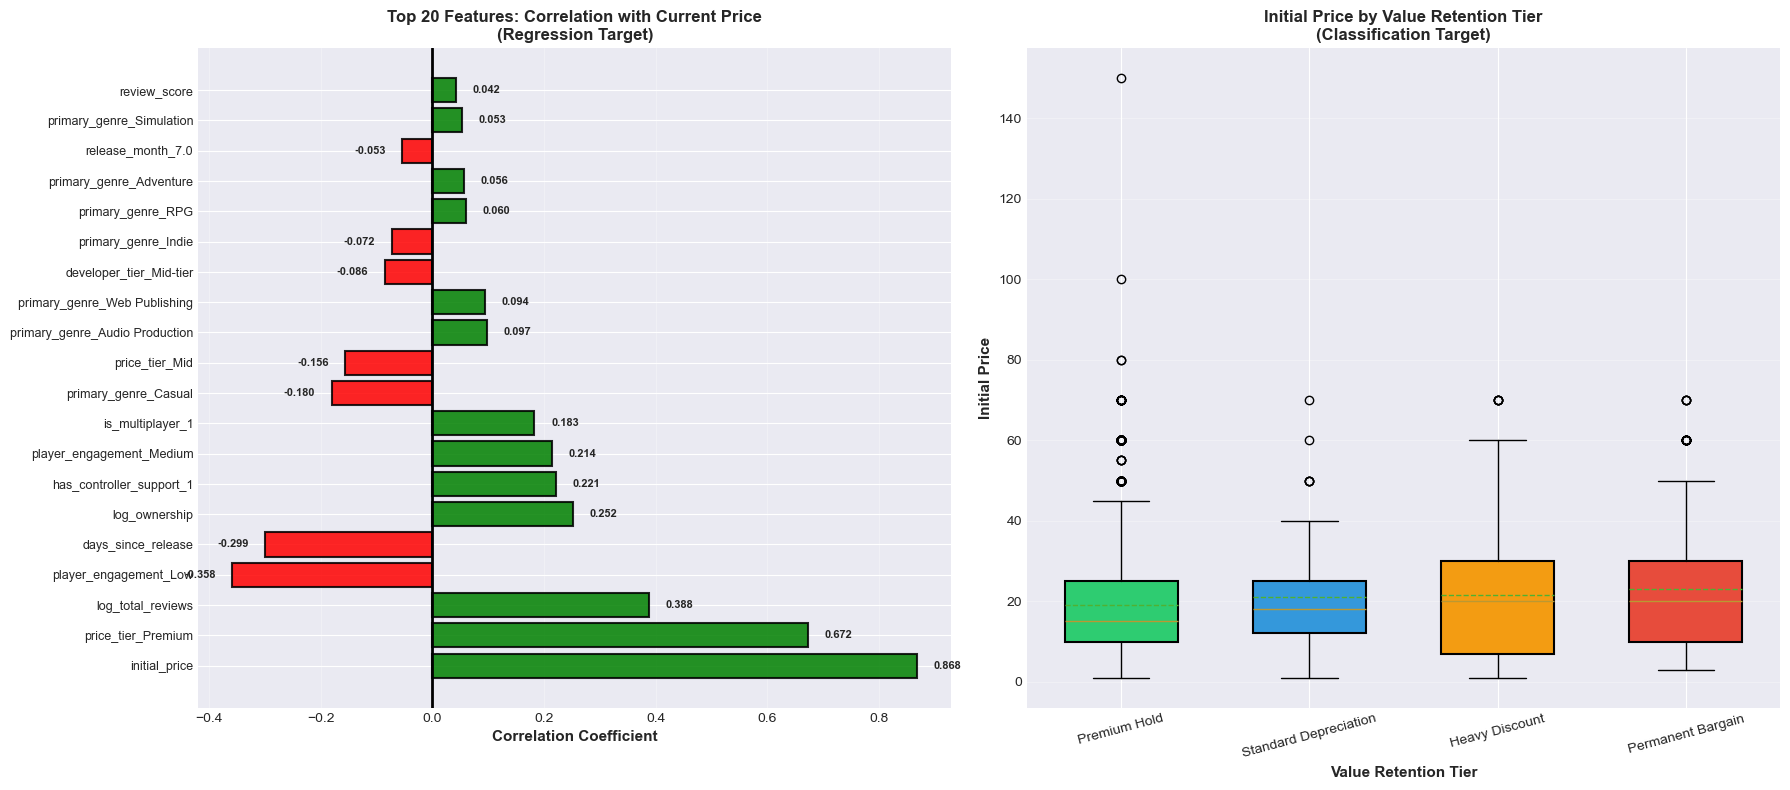


FEATURE IMPORTANCE: CORRELATION WITH CURRENT PRICE

Top 10 Features Overall (by absolute correlation):
 1. initial_price                                    |r|=0.868  (r=+0.868, Positive)
 2. price_tier_Premium                               |r|=0.672  (r=+0.672, Positive)
 3. log_total_reviews                                |r|=0.388  (r=+0.388, Positive)
 4. player_engagement_Low                            |r|=0.358  (r=-0.358, Negative)
 5. days_since_release                               |r|=0.299  (r=-0.299, Negative)
 6. log_ownership                                    |r|=0.252  (r=+0.252, Positive)
 7. has_controller_support_1                         |r|=0.221  (r=+0.221, Positive)
 8. player_engagement_Medium                         |r|=0.214  (r=+0.214, Positive)
 9. is_multiplayer_1                                 |r|=0.183  (r=+0.183, Positive)
10. primary_genre_Casual                             |r|=0.180  (r=-0.180, Negative)

Top 5 NUMERIC Features (excluding one-hot enc

In [26]:
# Feature correlations with target variables
# We need to use X_full (with encoded features) and align with current_price from df

# Get current_price aligned with X_full's index
y_price_aligned = df.loc[X_full.index, 'current_price']

# Create a dataframe with all features + target
X_with_target = X_full.copy()
X_with_target['current_price'] = y_price_aligned

# Calculate correlations
target_corr_price = X_with_target.corr()['current_price'].drop('current_price')
target_corr_sorted = target_corr_price.abs().sort_values(ascending=False)

# For visualization, show top 20 features (not all 56)
n_features_show = min(20, len(target_corr_sorted))
target_corr_sorted_top = target_corr_sorted.head(n_features_show)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Correlation with current_price (TOP FEATURES ONLY)
y_pos = np.arange(len(target_corr_sorted_top))
colors = ['red' if target_corr_price[feat] < 0 else 'green' 
         for feat in target_corr_sorted_top.index]

bars = axes[0].barh(y_pos, target_corr_price[target_corr_sorted_top.index],
                    color=colors, edgecolor='black', linewidth=1.5, alpha=0.85)
axes[0].set_yticks(y_pos)
# Truncate long feature names for display
display_names = [name[:35] + "..." if len(name) > 35 else name 
                 for name in target_corr_sorted_top.index]
axes[0].set_yticklabels(display_names, fontsize=9)
axes[0].set_xlabel('Correlation Coefficient', fontweight='bold', fontsize=11)
axes[0].set_title(f'Top {n_features_show} Features: Correlation with Current Price\n(Regression Target)',
                 fontweight='bold', fontsize=12)
axes[0].axvline(x=0, color='black', linewidth=2)
axes[0].grid(True, alpha=0.3, axis='x')

# Add value labels
for i, feature in enumerate(target_corr_sorted_top.index):
    corr = target_corr_price[feature]
    x_pos = corr + (0.03 if corr > 0 else -0.03)
    ha = 'left' if corr > 0 else 'right'
    axes[0].text(x_pos, i, f'{corr:.3f}', va='center', ha=ha, 
                fontweight='bold', fontsize=8)

# Box plots: key feature vs value_retention_tier
# Find the top NUMERIC feature (not one-hot encoded)
numeric_feature_corrs = target_corr_price[numeric_features]
key_feature = numeric_feature_corrs.abs().idxmax()

tier_order = ['Premium Hold', 'Standard Depreciation', 'Heavy Discount', 'Permanent Bargain']
tier_order = [t for t in tier_order if t in df['value_retention_tier'].unique()]

data_to_plot = [df[df['value_retention_tier'] == tier][key_feature].dropna()
                for tier in tier_order]

bp = axes[1].boxplot(data_to_plot, labels=tier_order, patch_artist=True,
                    widths=0.6, showmeans=True, meanline=True)

for patch, tier in zip(bp['boxes'], tier_order):
    patch.set_facecolor(TIER_COLORS.get(tier, PALETTE[0]))
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

axes[1].set_ylabel(key_feature.replace('_', ' ').title(), 
                  fontweight='bold', fontsize=11)
axes[1].set_xlabel('Value Retention Tier', fontweight='bold', fontsize=11)
axes[1].set_title(f'{key_feature.replace("_", " ").title()} by Value Retention Tier\n(Classification Target)',
                 fontweight='bold', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Print feature importance rankings
print("\n" + "="*80)
print("FEATURE IMPORTANCE: CORRELATION WITH CURRENT PRICE")
print("="*80)

print(f"\nTop 10 Features Overall (by absolute correlation):")
for i, feature in enumerate(target_corr_sorted.head(10).index, 1):
    abs_corr = target_corr_sorted[feature]
    corr = target_corr_price[feature]
    direction = "Positive" if corr > 0 else "Negative"
    # Truncate feature name
    feature_display = feature[:45] + "..." if len(feature) > 45 else feature
    print(f"{i:2d}. {feature_display:48} |r|={abs_corr:.3f}  (r={corr:+.3f}, {direction})")

print(f"\nTop 5 NUMERIC Features (excluding one-hot encoded):")
numeric_corr_sorted = numeric_feature_corrs.abs().sort_values(ascending=False)
for i, feature in enumerate(numeric_corr_sorted.head(5).index, 1):
    abs_corr = numeric_corr_sorted[feature]
    corr = target_corr_price[feature]
    direction = "Positive" if corr > 0 else "Negative"
    print(f"{i}. {feature:25} |r|={abs_corr:.3f}  (r={corr:+.3f}, {direction})")

print(f"\n📊 INTERPRETATION:")
top_feature = target_corr_sorted.index[0]
top_corr = target_corr_price[top_feature]
print(f"  • Strongest predictor overall: {top_feature}")
print(f"    Correlation: r={top_corr:+.3f}")

top_numeric = numeric_corr_sorted.index[0]
top_numeric_corr = target_corr_price[top_numeric]
print(f"  • Strongest NUMERIC predictor: {top_numeric}")
print(f"    Correlation: r={top_numeric_corr:+.3f}")

if abs(top_corr) > 0.7:
    print(f"\n  • STRONG correlation — this feature will dominate linear models")
elif abs(top_corr) > 0.3:
    print(f"\n  • MODERATE correlation — useful predictor but not dominant")
else:
    print(f"\n  • WEAK correlation — no single feature strongly predicts price")
    print(f"  • Complex models (trees, ensembles) may be needed")

print(f"\n💡 NOTE ON ONE-HOT ENCODED FEATURES:")
print(f"  • One-hot features (e.g., 'primary_genre_Action') show correlation")
print(f"  • But their interpretation is different from numeric features")
print(f"  • Example: 'primary_genre_RPG' r=+0.45 means RPGs tend to have higher prices")

---
## 6. Summary & Recommendations for Phase 4
---

In [28]:
print("="*80)
print("EDA SUMMARY & PHASE 4 RECOMMENDATIONS")
print("="*80)

print("\n" + "="*80)
print("1. DATASET CHARACTERISTICS")
print("="*80)
print(f"  • Total games: {len(df):,}")
print(f"  • Numerical features: {len(numeric_features)}")
print(f"  • Categorical features: {len(categorical_features)}")
print(f"  • Total features after encoding: {len(pca_features)}")
print(f"  • Missing data in X_full: {(X_full.isnull().sum().sum() / (len(X_full) * len(X_full.columns)) * 100):.2f}%")

print("\n" + "="*80)
print("2. TARGET VARIABLES")
print("="*80)
print("\n  REGRESSION (current_price):")
price_data = df['current_price'].dropna()
print(f"    • Mean: ₱{price_data.mean():.2f}, Median: ₱{price_data.median():.2f}")
print(f"    • Skewness: {price_data.skew():.2f}")
if price_data.skew() > 1:
    print(f"    • ⚠️ HIGHLY SKEWED — log transformation recommended")
print(f"    • Range: ₱{price_data.min():.2f} - ₱{price_data.max():.2f}")

print("\n  CLASSIFICATION (value_retention_tier):")
tier_counts = df['value_retention_tier'].value_counts()
if len(tier_counts) > 0:
    max_class = tier_counts.max()
    min_class = tier_counts.min()
    imbalance_ratio = max_class / min_class if min_class > 0 else np.inf
    print(f"    • Classes: {len(tier_counts)}")
    print(f"    • Imbalance ratio: {imbalance_ratio:.2f}:1")
    if imbalance_ratio > 10:
        print(f"    • ⚠️ SEVERE IMBALANCE — SMOTE or class_weight='balanced' REQUIRED")
    elif imbalance_ratio > 3:
        print(f"    • ⚠️ MODERATE IMBALANCE — class_weight='balanced' recommended")

print("\n" + "="*80)
print("3. DIMENSIONALITY REDUCTION INSIGHTS")
print("="*80)
print(f"  • Method: PCA (Principal Component Analysis)")
print(f"  • Original dimensions: {len(pca_features)}")
print(f"  • Components for 95% variance: {n_components_95}")
print(f"  • Dimensionality reduction: {(1 - n_components_95/len(pca_features))*100:.1f}%")
print(f"  • Top 2 PCs capture: {cumulative_variance_ratio[1]*100:.1f}% of variance")
print(f"\n  📊 DECISION: Use ORIGINAL FEATURES for modeling, not PCA components")
print(f"    Why?")
print(f"    • {len(numeric_features)} numeric + {len(categorical_features)} categorical = {len(pca_features)} total features")
print(f"    • Tree-based models (RF, XGBoost) don't require dimensionality reduction")
print(f"    • Interpretability is crucial for business insights")
print(f"    • Example: 'primary_genre_Action' is clearer than 'PC3 = 2.1'")
print(f"    • PCA was useful for understanding feature structure, not modeling")

print("\n" + "="*80)
print("4. MULTICOLLINEARITY ASSESSMENT")
print("="*80)
if high_corr_pairs:
    print(f"  ⚠️ {len(high_corr_pairs)} severe multicollinearity pairs (|r| > 0.9)")
    for feat1, feat2, corr in high_corr_pairs:
        print(f"    • {feat1} <-> {feat2}: r={corr:+.3f}")
    print(f"    ACTION: Remove one feature from each pair")
elif moderate_corr_pairs:
    print(f"  ⚠️ {len(moderate_corr_pairs)} moderate multicollinearity pairs (|r| > 0.7)")
    for feat1, feat2, corr in moderate_corr_pairs:
        print(f"    • {feat1} <-> {feat2}: r={corr:+.3f}")
    print(f"    RECOMMENDATION: Use regularization (Ridge) for linear models")
else:
    print(f"  ✓ No significant multicollinearity in numeric features (all |r| < 0.7)")
    print(f"    Numeric features are relatively independent — good for modeling")

print("\n" + "="*80)
print("5. FEATURE IMPORTANCE FOR CURRENT PRICE")
print("="*80)
print(f"  Top 5 predictors (all features):")
for i, feature in enumerate(target_corr_sorted.head(5).index, 1):
    corr = target_corr_price[feature]
    feature_display = feature[:40] + "..." if len(feature) > 40 else feature
    print(f"    {i}. {feature_display:43} (r={corr:+.3f})")

print(f"\n  Top 3 NUMERIC predictors:")
numeric_corr = target_corr_price[numeric_features].abs().sort_values(ascending=False)
for i, feature in enumerate(numeric_corr.head(3).index, 1):
    corr = target_corr_price[feature]
    print(f"    {i}. {feature:25} (r={corr:+.3f})")

print("\n" + "="*80)
print("6. PREPROCESSING RECOMMENDATIONS")
print("="*80)
print("  ✅ For ALL models:")
print("    • Handle missing values via median imputation (numerical) or mode (categorical)")
print("    • One-hot encode categorical variables (primary_genre, developer_tier, price_tier)")
print("    • Binary encode is_multiplayer and has_controller_support (already 0/1)")

print("\n  ✅ For REGRESSION models:")
if price_data.skew() > 1:
    print("    • Apply log transformation to current_price target: log1p(price)")
print("    • Use StandardScaler for all numerical features")
print("    • Consider polynomial features if linear models underperform")

print("\n  ✅ For CLASSIFICATION models:")
if imbalance_ratio > 3:
    print("    • CRITICAL: Set class_weight='balanced' in sklearn models")
    print("    • OR apply SMOTE to training data only (not test data)")
print("    • Use stratified sampling in train/test split")
print("    • Use StratifiedKFold for cross-validation")

print("\n" + "="*80)
print("7. MODEL SELECTION STRATEGY")
print("="*80)
print("  📊 REGRESSION (current_price prediction):")
print("    Baseline:")
print("      • Linear Regression (interpret coefficients)")
print("    Advanced:")
print("      • Random Forest Regressor (handles non-linearity)")
print("      • XGBoost Regressor (state-of-the-art performance)")
print("      • Ridge Regression (if multicollinearity is present)")
print("    Metrics: MAE, RMSE, R²")

print("\n  📊 CLASSIFICATION (value_retention_tier prediction):")
print("    Baseline:")
print("      • Logistic Regression with class_weight='balanced'")
print("    Advanced:")
print("      • Random Forest Classifier with class_weight='balanced'")
print("      • XGBoost Classifier (handles imbalance well)")
print("      • LightGBM Classifier (fast, accurate)")
print("    Metrics: F1-score (macro), Precision/Recall per class, ROC-AUC")

print("\n" + "="*80)
print("8. VALIDATION STRATEGY")
print("="*80)
print("  ✅ Train/Test Split:")
print("    • 80/20 split")
print("    • Stratified sampling for classification (stratify=y)")
print("    • Random sampling for regression")
print("    • Alternative: Temporal split (pre-2023 train, 2023+ test)")

print("\n  ✅ Cross-Validation:")
print("    • 5-fold StratifiedKFold for classification")
print("    • 5-fold KFold for regression")
print("    • Use for hyperparameter tuning (GridSearchCV)")

print("\n  ✅ Hyperparameter Tuning:")
print("    • Tree depth: [3, 5, 7, 10]")
print("    • Learning rate: [0.01, 0.05, 0.1]")
print("    • n_estimators: [100, 200, 500]")
print("    • Use RandomizedSearchCV for faster tuning")

print("\n" + "="*80)
print("9. FEATURE ENGINEERING IDEAS")
print("="*80)
print("  💡 Interaction features:")
print("    • price_per_achievement = initial_price / (achievements_total + 1)")
print("    • review_velocity = total_reviews / days_since_release")
print("    • ownership_per_day = log_ownership / days_since_release")

print("\n  💡 Polynomial features:")
print("    • days_since_release² (capture non-linear depreciation)")
print("    • log_ownership × initial_price (scale × price interaction)")

print("\n  💡 Temporal features:")
print("    • release_season (from release_month)")
print("    • is_recent (released in last 2 years)")

print("\n" + "="*80)
print("✅ EDA COMPLETE — READY FOR PHASE 4 MODEL DEVELOPMENT")
print("="*80)

print("\n📌 NEXT STEPS:")
print("  1. Open 04_ml_part1_price_and_value_retention.ipynb")
print("  2. Implement preprocessing pipeline based on these recommendations")
print("  3. Train baseline models (Linear/Logistic Regression)")
print("  4. Train advanced models (RF, XGBoost, LightGBM)")
print("  5. Compare performance and select best model")
print("  6. Extract feature importances and interpret results")

EDA SUMMARY & PHASE 4 RECOMMENDATIONS

1. DATASET CHARACTERISTICS
  • Total games: 3,987
  • Numerical features: 6
  • Categorical features: 7
  • Total features after encoding: 48
  • Missing data in X_full: 0.00%

2. TARGET VARIABLES

  REGRESSION (current_price):
    • Mean: ₱17.23, Median: ₱14.99
    • Skewness: 1.59
    • ⚠️ HIGHLY SKEWED — log transformation recommended
    • Range: ₱0.00 - ₱149.99

  CLASSIFICATION (value_retention_tier):
    • Classes: 5
    • Imbalance ratio: 37.97:1
    • ⚠️ SEVERE IMBALANCE — SMOTE or class_weight='balanced' REQUIRED

3. DIMENSIONALITY REDUCTION INSIGHTS
  • Method: PCA (Principal Component Analysis)
  • Original dimensions: 48
  • Components for 95% variance: 40
  • Dimensionality reduction: 16.7%
  • Top 2 PCs capture: 11.3% of variance

  📊 DECISION: Use ORIGINAL FEATURES for modeling, not PCA components
    Why?
    • 6 numeric + 7 categorical = 48 total features
    • Tree-based models (RF, XGBoost) don't require dimensionality reductio

In [29]:
# Close database connection
conn.close()
print("\n✓ Database connection closed")
print("\n🎯 Phase 3 (EDA) complete! Ready for Phase 4 (ML modeling)")


✓ Database connection closed

🎯 Phase 3 (EDA) complete! Ready for Phase 4 (ML modeling)
